# Lab 7- Data Analysis

Exercises 1-4 are to be completed by October 25th. The remaider of the lab is due November 1st. Before leaving lab today, everyone must download the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [3]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

--2026-03-27 17:21:33--  http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘SUSY.csv.gz’

SUSY.csv.gz             [         <=>        ] 879.65M  2.04MB/s    in 3m 48s  

2026-03-27 17:25:27 (3.86 MB/s) - ‘SUSY.csv.gz’ saved [922377711]



In [1]:
##!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  8322k      0 --:--:--  0:01:48 --:--:-- 6914k--  0:00:04 --:--:-- 28.0M   0 --:--:--  0:00:36 --:--:-- 8380k-  0:01:02 --:--:-- 3841k  9488k      0 --:--:--  0:01:03 --:--:-- 3333k--:--:--  0:01:08 --:--:-- 4464kk      0 --:--:--  0:01:22 --:--:-- 6746k      0 --:--:--  0:01:30 --:--:-- 10.0M-:--:--  0:01:31 --:--:-- 9675k01:40 --:--:-- 5977k


In [4]:
##!rm SUSY.csv

In [4]:
##!gunzip SUSY.csv.gz

In [5]:
#ls -lh

total 2.3G
-rwxrwxrwx 1 pearl pearl 390K Mar 26 21:26 Lab.7.ipynb*
-rwxrwxrwx 1 pearl pearl 5.9M Mar  5 01:44 Lab.7.pdf*
-rwxrwxrwx 1 pearl pearl 392K Mar 27 17:33 Lab.7.submission.ipynb*
-rwxrwxrwx 1 pearl pearl 2.3G Mar 27 17:25 SUSY.csv*


The data is provided as a comma separated file.

In [6]:
#filename="SUSY.csv"
# print out the first 5 lines using unix head command
#!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
#!ls -lh

total 2.3G
-rwxrwxrwx 1 pearl pearl 390K Mar 26 21:26 Lab.7.ipynb
-rwxrwxrwx 1 pearl pearl 5.9M Mar  5 01:44 Lab.7.pdf
-rwxrwxrwx 1 pearl pearl 392K Mar 27 17:35 Lab.7.submission.ipynb
-rwxrwxrwx 1 pearl pearl 2.3G Mar 27 17:25 SUSY.csv


We see that we have 5 million datapoints.

In [8]:
#!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [10]:
#!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
#ls -lh

total 2.5G
-rwxrwxrwx 1 pearl pearl 390K Mar 26 21:26 Lab.7.ipynb*
-rwxrwxrwx 1 pearl pearl 5.9M Mar  5 01:44 Lab.7.pdf*
-rwxrwxrwx 1 pearl pearl 392K Mar 27 17:41 Lab.7.submission.ipynb*
-rwxrwxrwx 1 pearl pearl 228M Mar 27 17:41 SUSY-small.csv*
-rwxrwxrwx 1 pearl pearl 2.3G Mar 27 17:25 SUSY.csv*


In [12]:
#! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [1]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [2]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [3]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [4]:
FeatureNames

['MET_rel',
 'R',
 'dPhi_r_b',
 'M_TR_2',
 'M_R',
 'M_Delta_R',
 'cos_theta_r1',
 'MT2',
 'S_R',
 'axial_MET']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [6]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [7]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [8]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


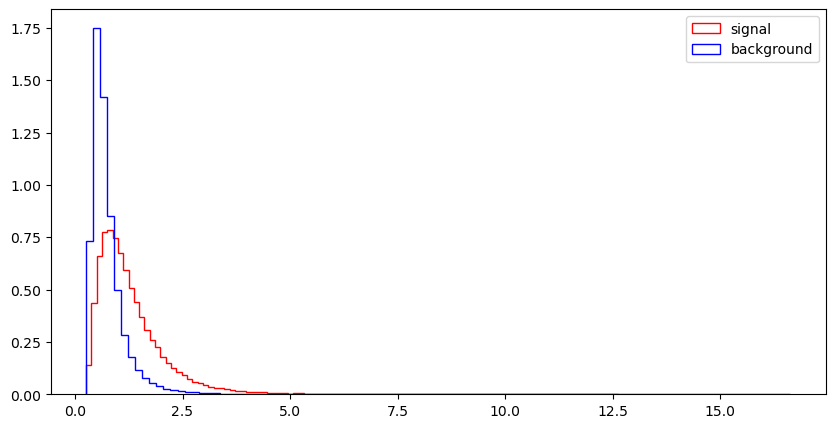

l_1_eta


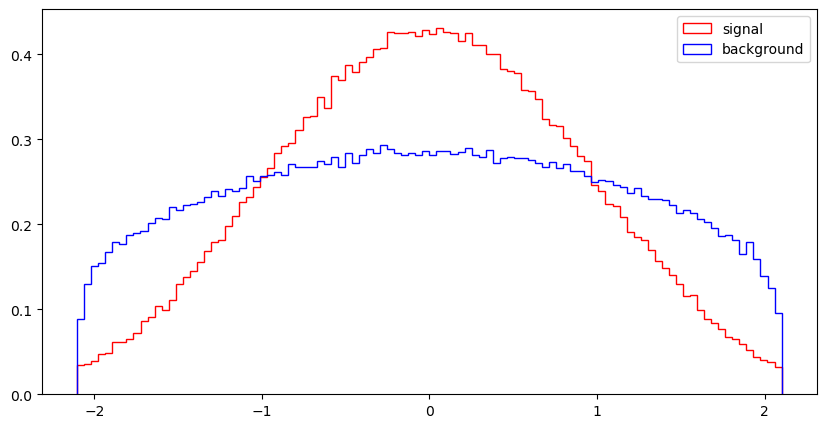

l_1_phi


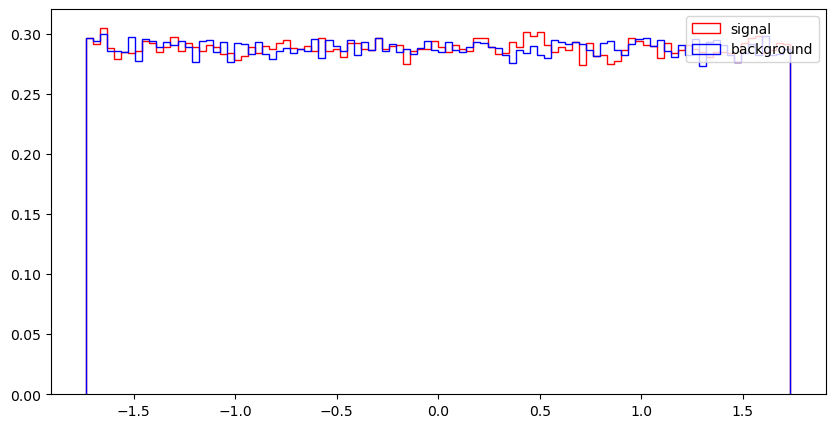

l_2_pT


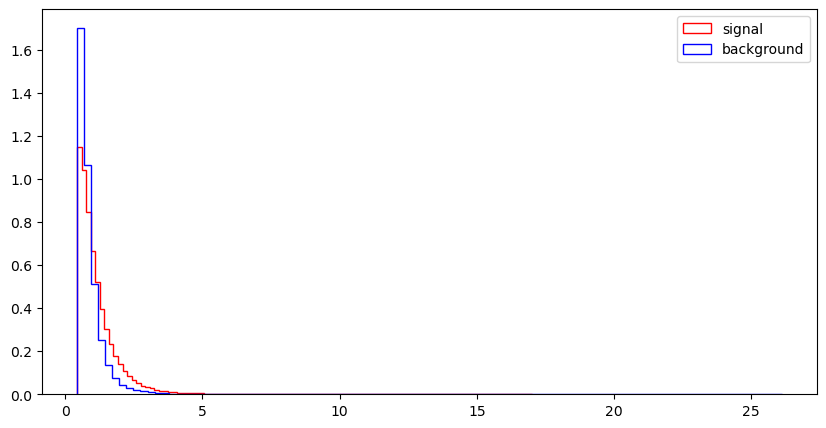

l_2_eta


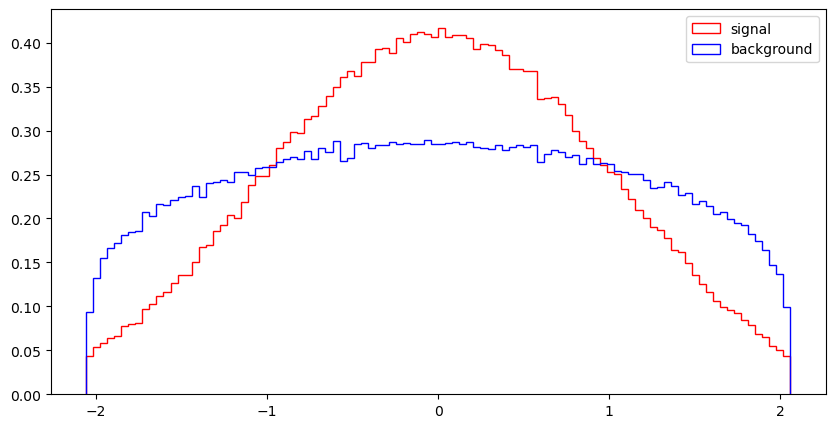

l_2_phi


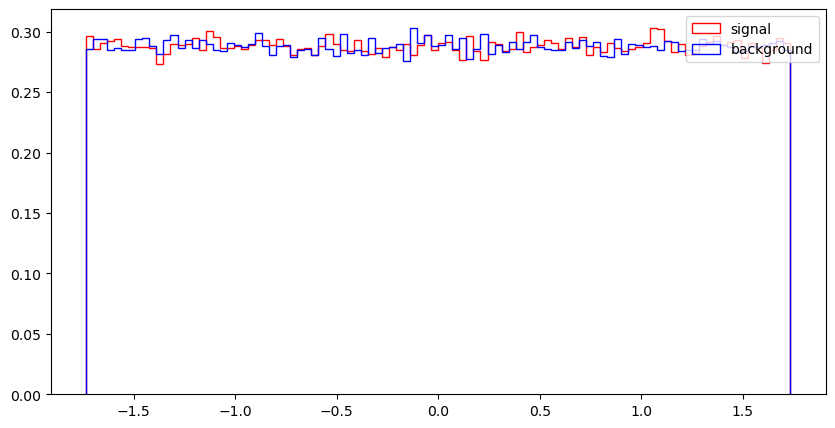

MET


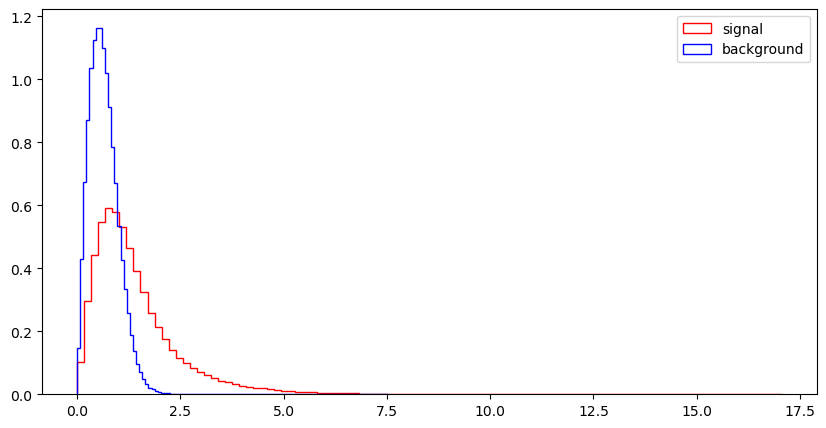

MET_phi


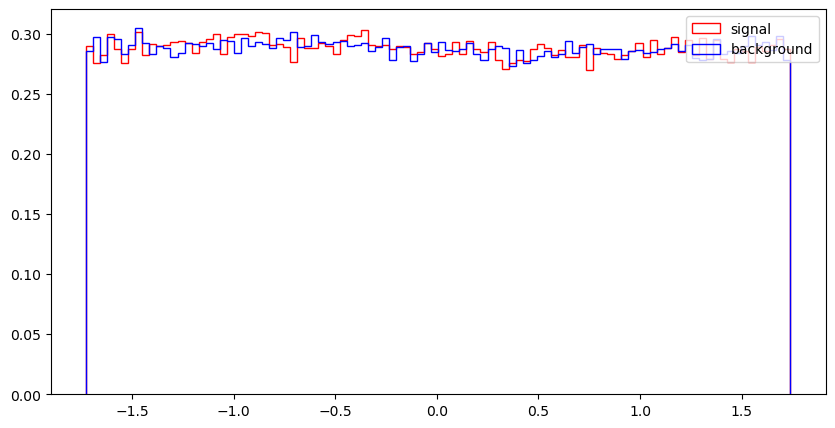

MET_rel


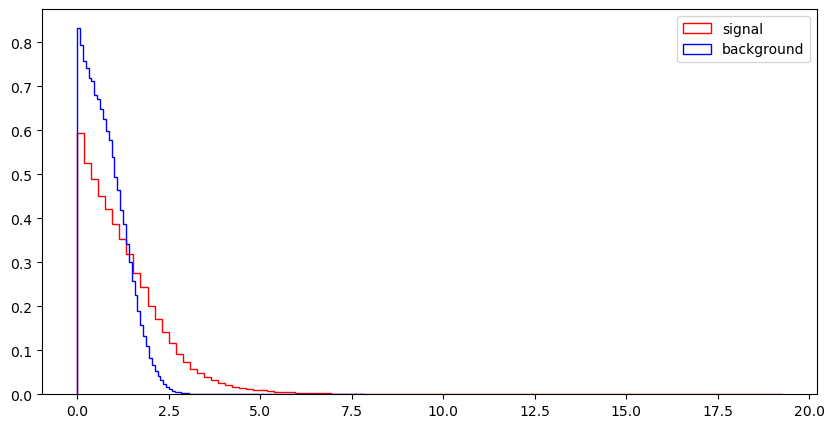

axial_MET


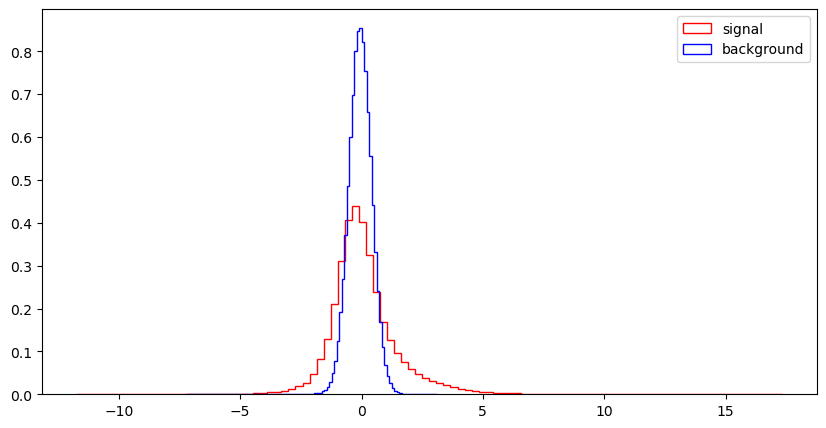

M_R


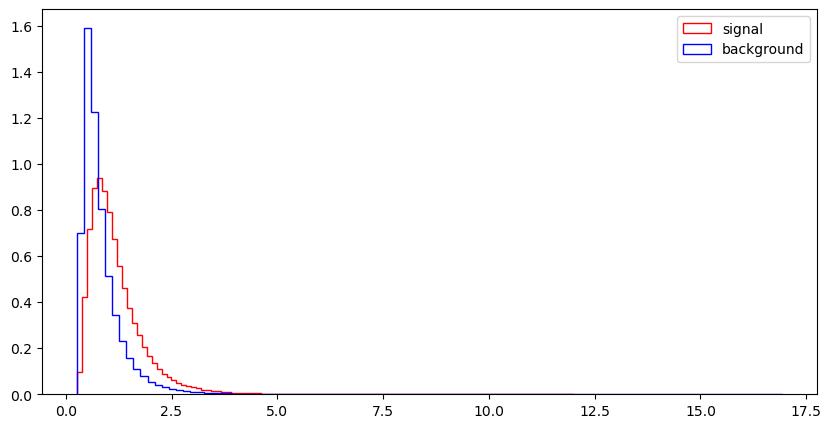

M_TR_2


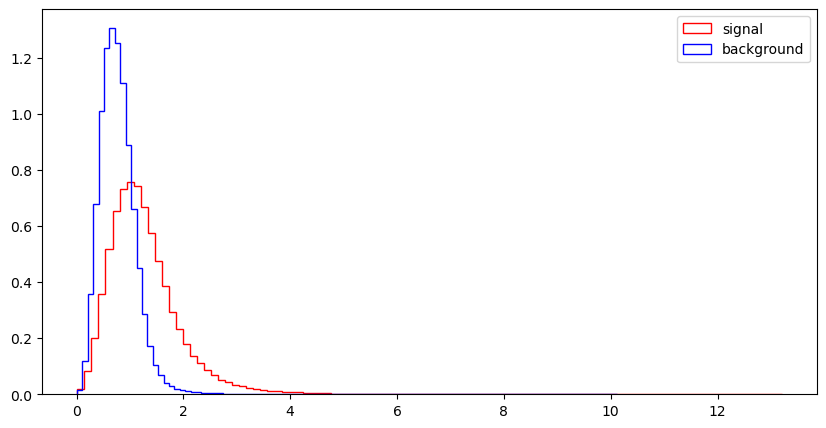

R


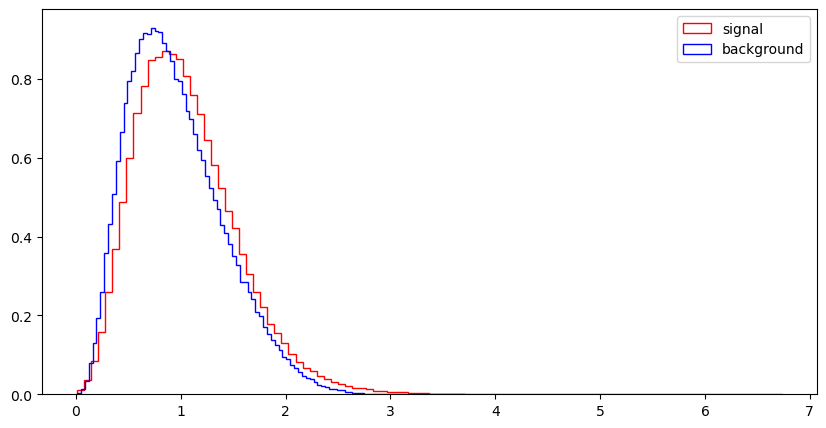

MT2


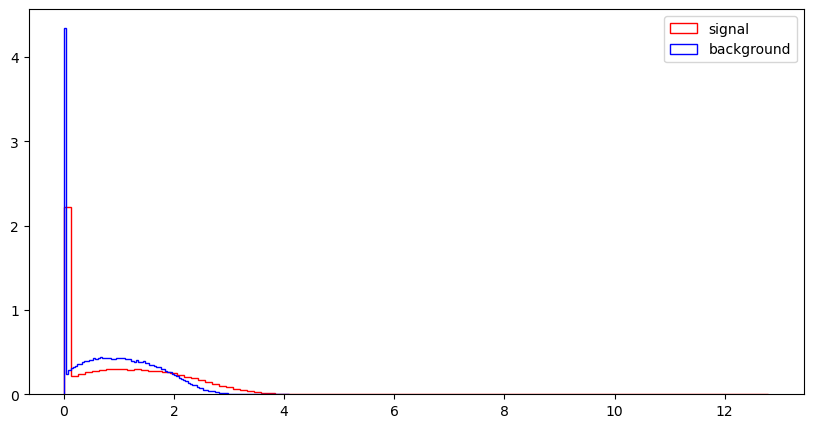

S_R


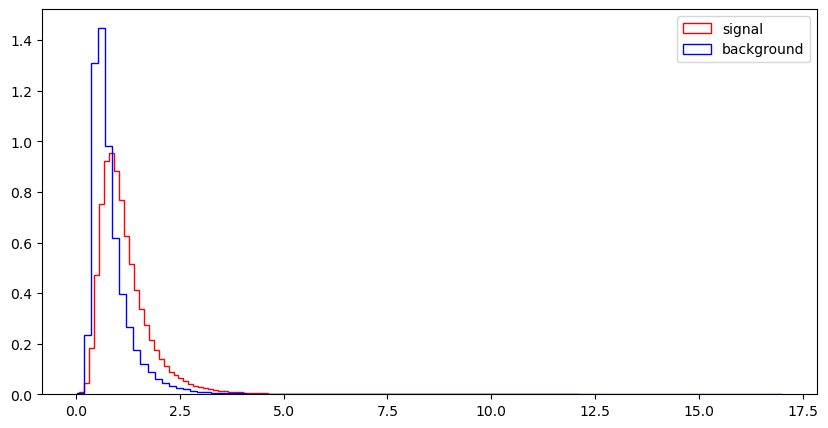

M_Delta_R


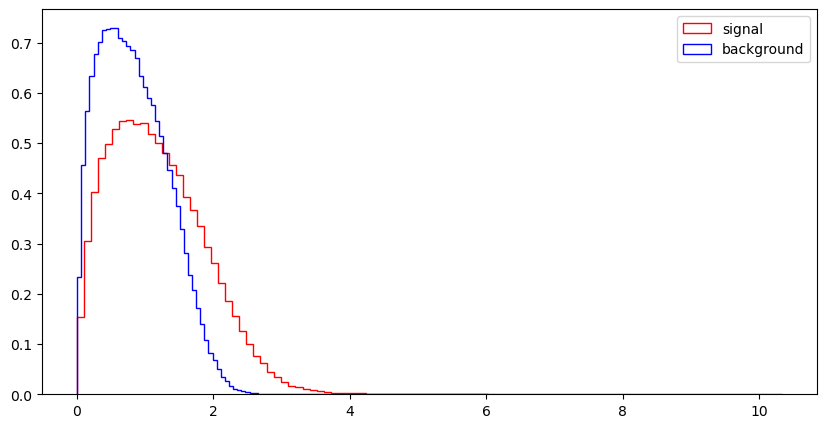

dPhi_r_b


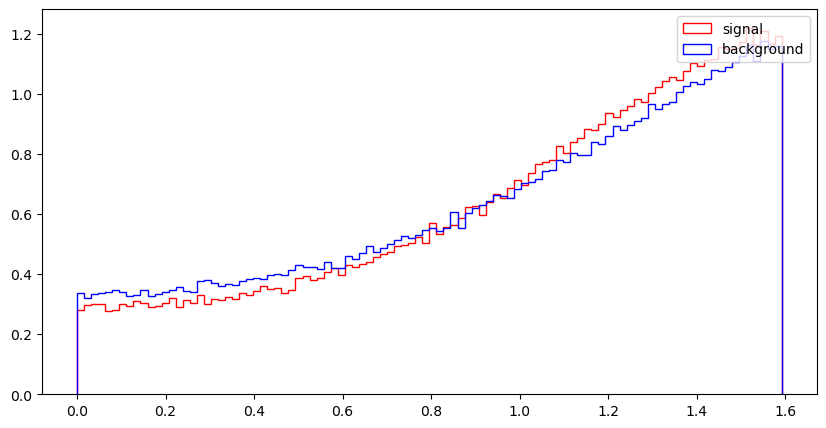

cos_theta_r1


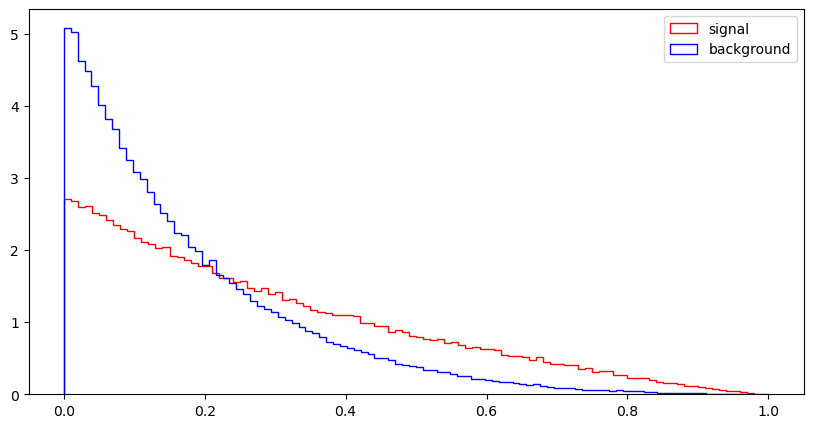

In [9]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

VarNames = [   ## column names for the SUSY dataset
     "signal",
    "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi",
    "MET_rel", "axial_MET", "M_R", "M_TR_2",
    "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

filename="SUSY-small.csv"
df=pd.read_csv(filename, names=VarNames)

sig=df[df["signal"] == 1]  ## spliting into signal and background
bkg=df[df["signal"] == 0]


print(df.shape)
print(sig.shape)
print(bkg.shape)

(500000, 19)
(229245, 19)
(270755, 19)


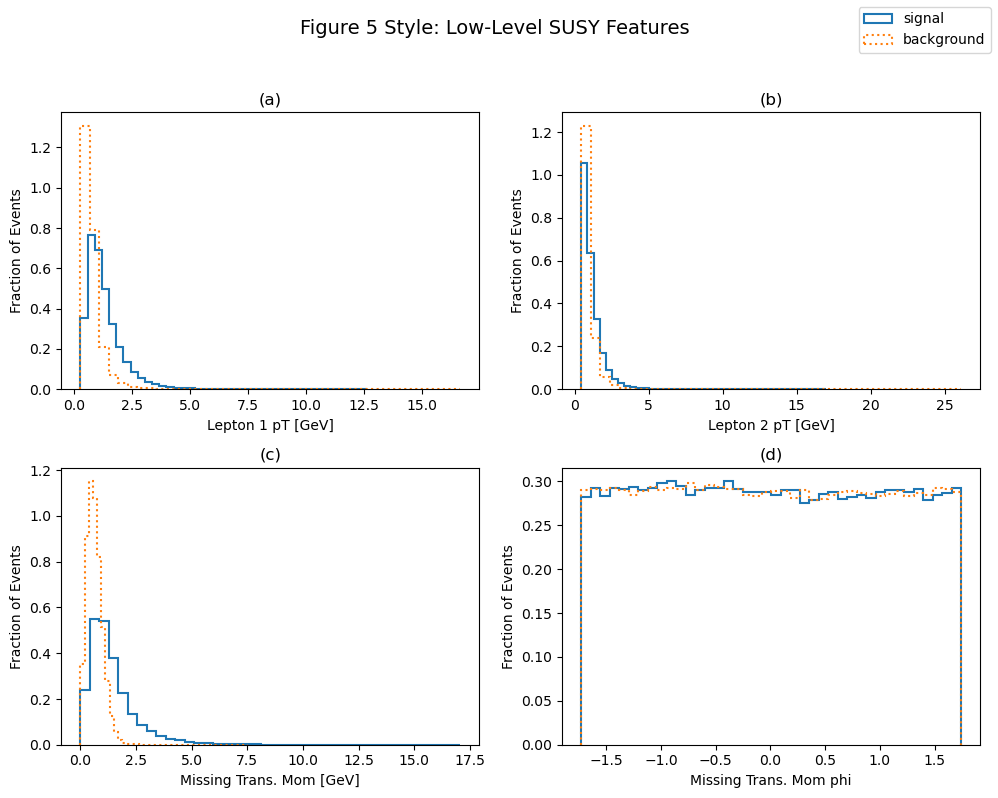

In [11]:
##trying to make figures like the ones in figure 5 of the paper

low_features=["l_1_pT", "l_2_pT", "MET"]
low_titles=[
    "Lepton 1 pT [GeV]",
    "Lepton 2 pT [GeV]",
    "Missing Trans. Mom [GeV]"]

fig, axes=plt.subplots(2, 2, figsize=(10, 8))
axes=axes.flatten()

for i in range(len(low_features)):   ## plotting the first three low-level variables
    feature=low_features[i]
    ax=axes[i]

    ax.hist(sig[feature], bins=40, density=True, histtype="step", linewidth=1.5, label="signal")
    ax.hist(bkg[feature], bins=40, density=True, histtype="step", linestyle="dotted", linewidth=1.5, label="background")

    ax.set_xlabel(low_titles[i])
    ax.set_ylabel("Fraction of Events")
    ax.set_title("(" + chr(97+i) + ")")

## got a bit confused here to asked LLM to guide on what should go next
ax =axes[3]
ax.hist(sig["MET_phi"], bins=40, density=True, histtype="step",
        linewidth=1.5, label="signal")
ax.hist(bkg["MET_phi"], bins=40, density=True, histtype="step",
        linestyle="dotted", linewidth=1.5, label="background")
ax.set_xlabel("Missing Trans. Mom phi")
ax.set_ylabel("Fraction of Events")
ax.set_title("(d)")

## got LLM help to figure out if anything else was missing in my answer and then added the legend and heading as it suggested

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle("Figure 5 Style: Low-Level SUSY Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

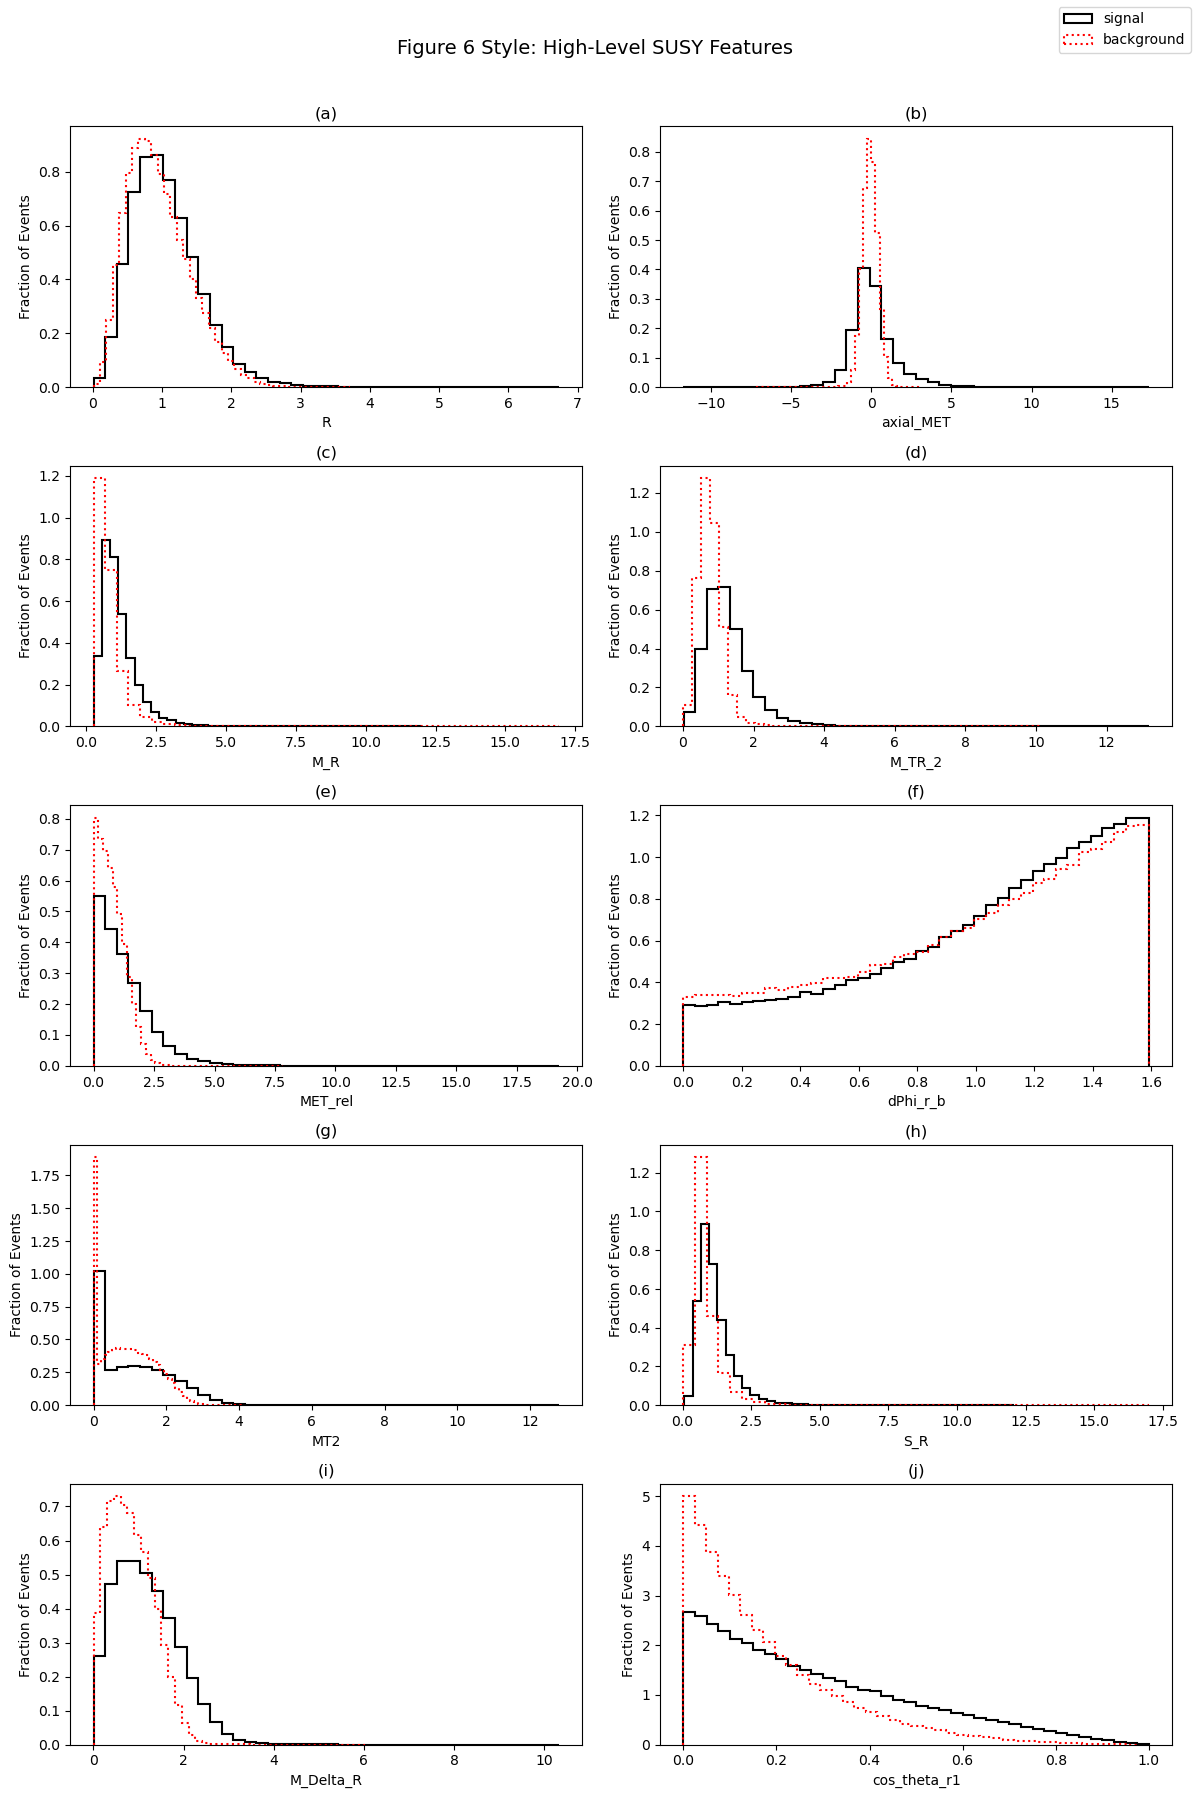

In [12]:
high_features = [
    "R", "axial_MET",
    "M_R", "M_TR_2",
    "MET_rel", "dPhi_r_b",
    "MT2", "S_R",
    "M_Delta_R", "cos_theta_r1"]

fig, axes=plt.subplots(5, 2, figsize=(12, 18))
axes=axes.flatten()

for i in range(len(high_features)):
    feature=high_features[i]
    ax=axes[i]

    ax.hist(sig[feature], bins=40, density=True, histtype="step",
            color="black", linewidth=1.5, label="signal")
    ax.hist(bkg[feature], bins=40, density=True, histtype="step",
            color="red", linestyle="dotted", linewidth=1.5, label="background")

    ax.set_xlabel(feature)
    ax.set_ylabel("Fraction of Events")
    ax.set_title("(" + chr(97 + i) + ")")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle("Figure 6 Style: High-Level SUSY Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [13]:
## a :
## used LLM here to get an outline so  i can have a clear idea
import matplotlib.pyplot as plt

## plan: diagonal -> histogram; off-diagonal -> scatter plot
def make_pairplot(data, columns, title, sample_size=500):
    
    plot_data=data[columns].sample(sample_size, random_state=1)    
    n=len(columns)
    fig, axes=plt.subplots(n, n, figsize=(3*n, 3*n))
    
    for i in range(n):
        for j in range(n):
            ax=axes[i, j]
                        
            if i == j:  ## diagonal : histogram of one variable
                ax.hist(plot_data[columns[i]], bins=25, color="lightgray", edgecolor="black")
                        
            else:  ## off-diagonal : scatter plot of two variables
                ax.scatter(plot_data[columns[j]], plot_data[columns[i]], s=4, alpha=0.4)
                      
            if i == n - 1:  ## for showing x labels on just the bottom row
                ax.set_xlabel(columns[j])
            else:
                ax.set_xticklabels([])
                        
            if j == 0:  ## for showing y labels on just the first column
                ax.set_ylabel(columns[i])
            else:
                ax.set_yticklabels([])
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

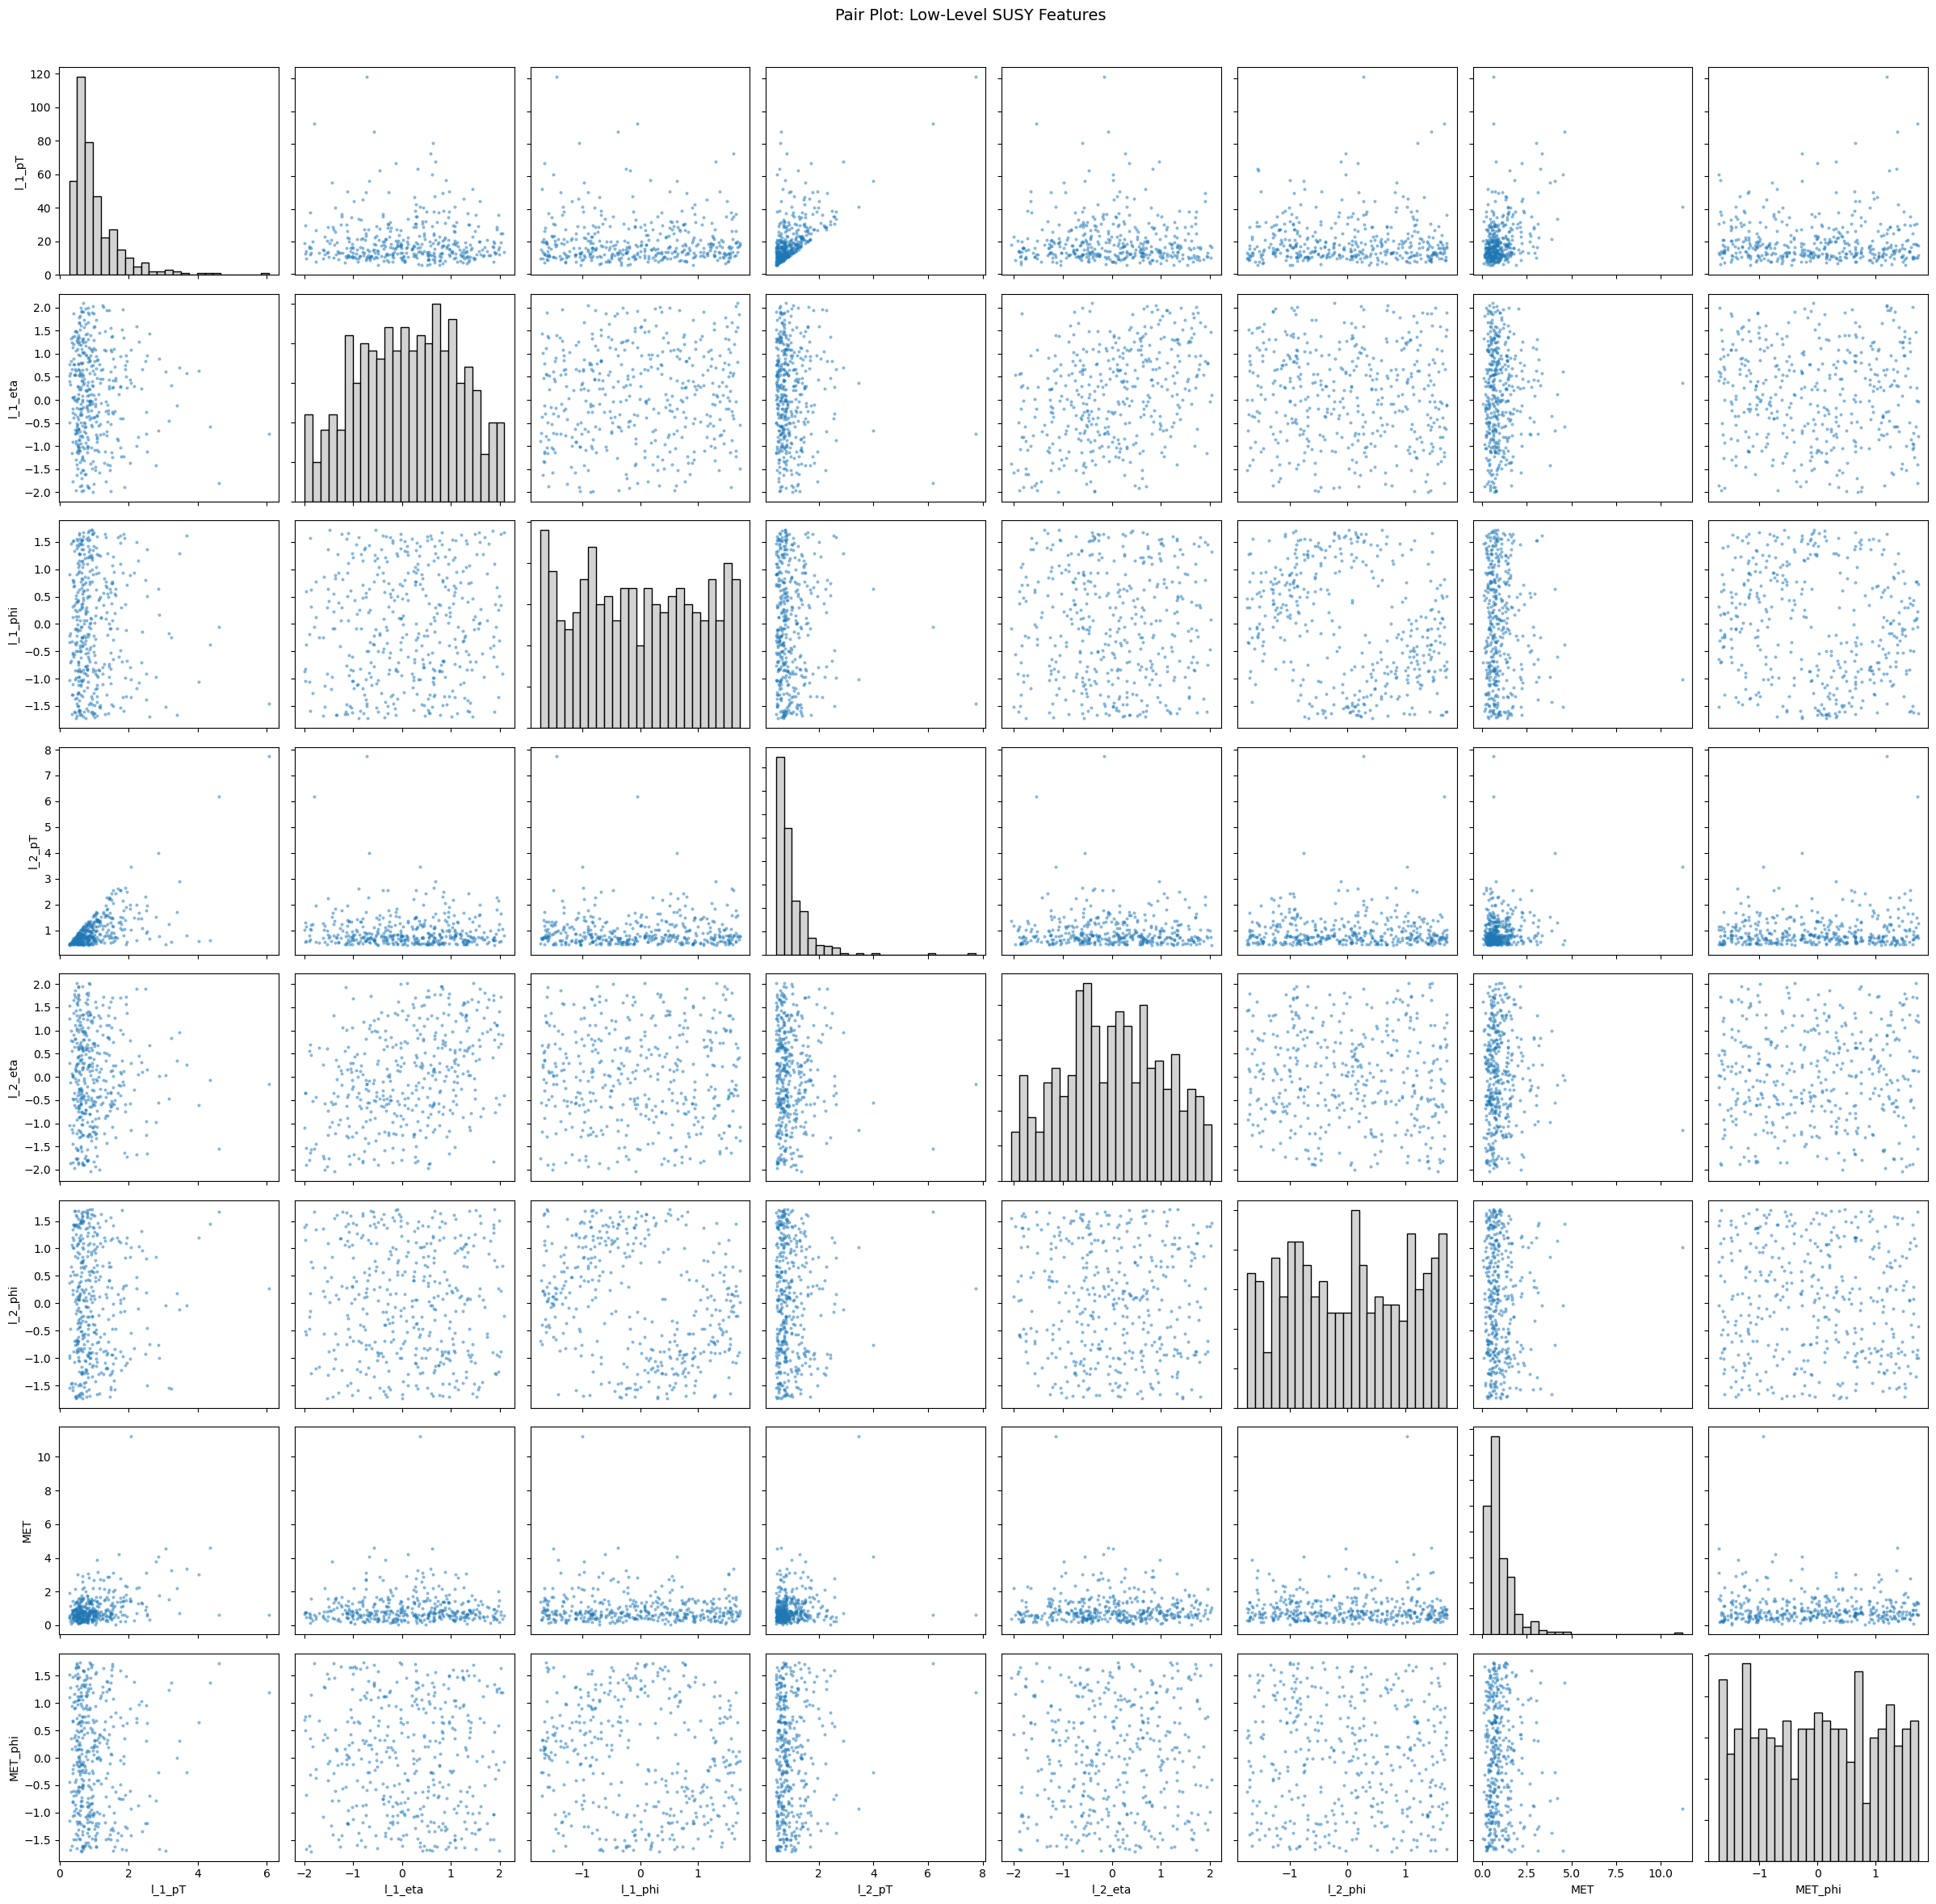

In [14]:
## low-level SUSY features
low_features=[
    "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi"]

make_pairplot(df, low_features, "Pair Plot: Low-Level SUSY Features", sample_size=400)

## chcecked with LLM if my ouput seemed correct

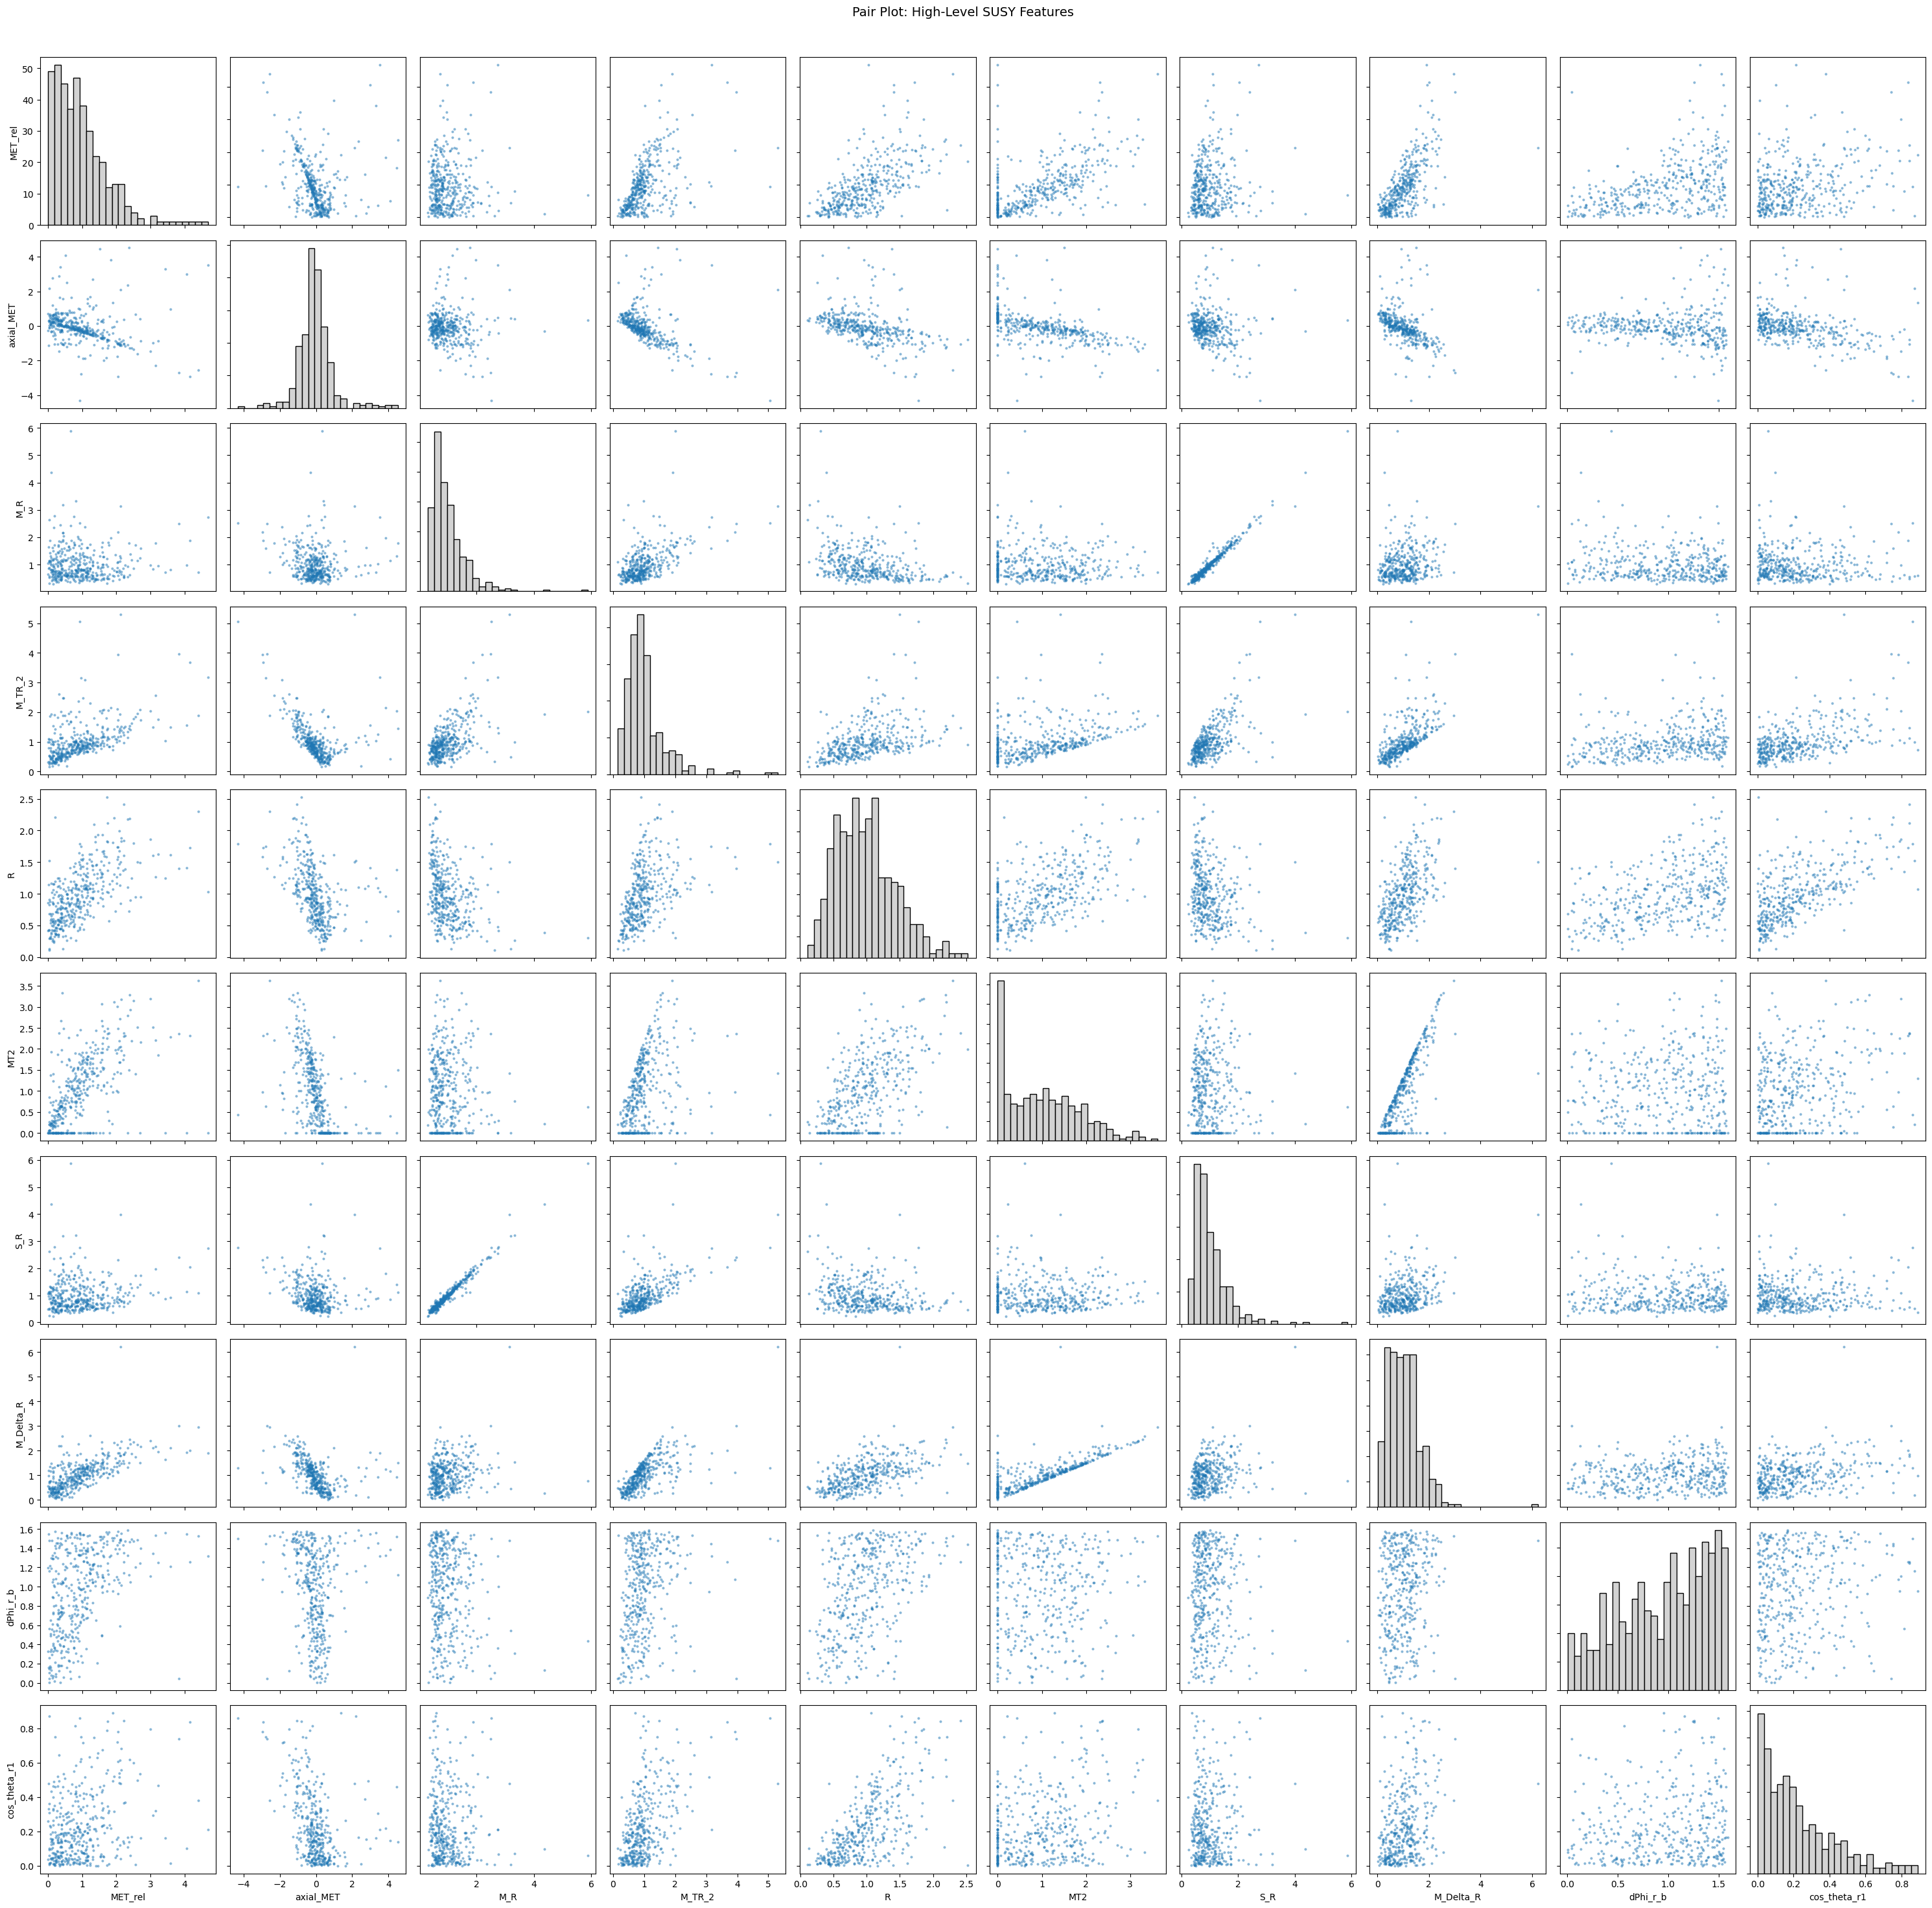

In [15]:
## high-level SUSY features
high_features=[
    "MET_rel", "axial_MET", "M_R", "M_TR_2",
    "R", "MT2", "S_R", "M_Delta_R",
    "dPhi_r_b", "cos_theta_r1"]

make_pairplot(df, high_features, "Pair Plot: High-Level SUSY Features", sample_size=400)

## chcecked with LLM if my ouput seemed correct

In [16]:
## b 

# A simple change made to speed up the pair plot was using only a random sample of the dataset in the function. 
# Plotting the full dataset for every subplot takes longer, so using a smaller sample makes the figure generate in lesser amount of time
# while still showing the general pattern. I even used smaller number of bins for the histograms, to reduce the plotting time.
# Another method that could be faster is using numpy.histogram to calculate the histogram values first, and then plotting those values.

In [17]:
## c :
# I think R, M_R, M_TR_2, MT2 and S_R have the best observables for separating the signal from background
# They show clear distinctions in signal and background distributions
# Overall high level SUSY features perform better than low-level SUSY features.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [18]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [19]:
## a : had problems with this, used LLM to help me figure it out
!pip install tabulate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [21]:
from tabulate import tabulate

In [40]:
import sys
!{sys.executable} -m pip install tabulate

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [22]:
import sys
print(sys.executable)

/usr/bin/python3


In [23]:
!/usr/bin/python3 -m pip install tabulate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [20]:
from tabulate import tabulate
print("tabulate imported successfully")

tabulate imported successfully


In [21]:
## b :
import numpy as np

low_features=[    ## low-level features
    "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi"]

high_features=[    ## high-level features
    "MET_rel", "axial_MET", "M_R", "M_TR_2",
    "R", "MT2", "S_R", "M_Delta_R",
    "dPhi_r_b", "cos_theta_r1"]

all_features=low_features + high_features

## converting selected columns to numpy array and using .T for putting variables as rows
all_data=df[all_features].to_numpy().T

## covariance matrix for all observables
cov_all=np.cov(all_data)

## correlation matrix for all observables
corr_all=np.corrcoef(all_data)

print("Covariance matrix for all observables:")
print(cov_all)

print("\nCorrelation matrix for all observables:")
print(corr_all)

Covariance matrix for all observables:
[[ 4.67481925e-01 -3.96674207e-04  7.66214265e-05  3.05037988e-01
  -3.48826988e-04  7.37336647e-04  2.28434336e-01 -9.36714374e-04
   9.75240349e-02 -9.73253567e-03  3.64432455e-01  2.87223483e-01
  -5.97024601e-02 -1.23988205e-02  3.42587023e-01  9.77389248e-02
  -4.69491360e-02  2.21632465e-02]
 [-3.96674207e-04  1.00430144e+00 -8.57630732e-04 -1.62905654e-04
   4.08312894e-01 -1.04201049e-03 -2.14697798e-03 -5.88968323e-04
  -1.37057212e-03 -1.10889241e-03 -5.53826632e-04 -6.68920291e-04
   3.01299870e-04  4.27122683e-04 -6.04009571e-04 -9.87471350e-04
  -7.40330277e-04  3.21632240e-04]
 [ 7.66214265e-05 -8.57630732e-04  1.00397336e+00  1.31296001e-03
   2.50714928e-04 -2.66810178e-01  7.66365893e-04 -1.84803977e-01
   7.06206018e-04 -1.87269105e-03  1.06306621e-03  8.68782730e-04
   2.01595554e-04  1.06029189e-03  1.46376567e-03  9.01233064e-04
   9.94305740e-04  2.59098396e-04]
 [ 3.05037988e-01 -1.62905654e-04  1.31296001e-03  4.25490163e-0

In [22]:
## low-level features matrix
low_data=df[low_features].to_numpy().T

cov_low=np.cov(low_data)  ## covariance matrix for low-level observables
corr_low=np.corrcoef(low_data)  ## correlation matrix for low-level observables

print("Covariance matrix for low-level features:")
print(cov_low)

print("\nCorrelation matrix for low-level features:")
print(corr_low)

Covariance matrix for low-level features:
[[ 4.67481925e-01 -3.96674207e-04  7.66214265e-05  3.05037988e-01
  -3.48826988e-04  7.37336647e-04  2.28434336e-01 -9.36714374e-04]
 [-3.96674207e-04  1.00430144e+00 -8.57630732e-04 -1.62905654e-04
   4.08312894e-01 -1.04201049e-03 -2.14697798e-03 -5.88968323e-04]
 [ 7.66214265e-05 -8.57630732e-04  1.00397336e+00  1.31296001e-03
   2.50714928e-04 -2.66810178e-01  7.66365893e-04 -1.84803977e-01]
 [ 3.05037988e-01 -1.62905654e-04  1.31296001e-03  4.25490163e-01
  -5.75571383e-04  1.55883996e-04  7.94518800e-02 -1.56177040e-03]
 [-3.48826988e-04  4.08312894e-01  2.50714928e-04 -5.75571383e-04
   1.00626446e+00  4.41588261e-04  3.81652056e-04 -3.22449476e-04]
 [ 7.37336647e-04 -1.04201049e-03 -2.66810178e-01  1.55883996e-04
   4.41588261e-04  1.00379832e+00 -3.03975643e-04 -3.54343031e-02]
 [ 2.28434336e-01 -2.14697798e-03  7.66365893e-04  7.94518800e-02
   3.81652056e-04 -3.03975643e-04  7.62248700e-01 -2.79212918e-03]
 [-9.36714374e-04 -5.889683

In [23]:
## high-level features matrix
high_data=df[high_features].to_numpy().T

cov_high=np.cov(high_data) ## covariance matrix for high-level observables
corr_high=np.corrcoef(high_data)   ## correlation matrix for high-level observables

print("Covariance matrix for high-level features:")
print(cov_high)

print("\nCorrelation matrix for high-level features:")
print(corr_high)

Covariance matrix for high-level features:
[[ 0.79048911 -0.1198512   0.04368455  0.30199264  0.24882357  0.40877889
   0.08231538  0.41474304  0.1464394   0.05531787]
 [-0.1198512   1.00537396  0.01713455 -0.18501679 -0.18090014 -0.46099861
  -0.04138282 -0.23307398 -0.02511279 -0.05373485]
 [ 0.04368455  0.01713455  0.39216708  0.20987467 -0.11290414 -0.03654441
   0.37976344  0.07393003 -0.02896168 -0.01434118]
 [ 0.30199264 -0.18501679  0.20987467  0.33782719  0.10401425  0.18916951
   0.2281247   0.24186516  0.05813297  0.05166586]
 [ 0.24882357 -0.18090014 -0.11290414  0.10401425  0.22157807  0.23210005
  -0.08335872  0.16548304  0.08709136  0.05816081]
 [ 0.40877889 -0.46099861 -0.03654441  0.18916951  0.23210005  0.73766054
  -0.01103752  0.43289693  0.02089723  0.04462891]
 [ 0.08231538 -0.04138282  0.37976344  0.2281247  -0.08335872 -0.01103752
   0.38201461  0.0957808  -0.00345651 -0.0103629 ]
 [ 0.41474304 -0.23307398  0.07393003  0.24186516  0.16548304  0.43289693
   0.095

In [24]:
##c:

## for rounding values to avoid scientific notation
cov_all_round=np.round(cov_all, 3)
corr_all_round=np.round(corr_all, 3) 

print("Covariance Matrix (All Observables)\n")

## I was struggling a little with this, asked LLM to give hints on how to go about this

print(tabulate(
    cov_all_round,
    headers=all_features,
    showindex=all_features,
    tablefmt="grid" ))

print("\nCorrelation Matrix (All Observables)\n")

print(tabulate(
    corr_all_round,
    headers=all_features,
    showindex=all_features,
    tablefmt="grid" ))

Covariance Matrix (All Observables)

+--------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+==========+===========+===========+==========+===========+===========+========+===========+===========+=============+========+==========+========+========+========+=============+============+================+
| l_1_pT       |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.01  |  0.364 |    0.287 | -0.06  | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
+--------------+----------+-----------+-----------+----------+-

In [25]:
## the output didn't look right, so i asked LLM to help with formatting
## but it kept using other packages and i didn't understand how to do it

In [26]:
## low level tables
cov_low_round=np.round(cov_low, 3)
corr_low_round=np.round(corr_low, 3)

print("Covariance Matrix (Low-Level Features)\n")

print(tabulate(
    cov_low_round,
    headers=low_features,
    showindex=low_features,
    tablefmt="grid"
))

print("\nCorrelation Matrix (Low-Level Features)\n")

print(tabulate(
    corr_low_round,
    headers=low_features,
    showindex=low_features,
    tablefmt="grid"
))

Covariance Matrix (Low-Level Features)

+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
+=========+==========+===========+===========+==========+===========+===========+========+===========+
| l_1_pT  |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_eta |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_phi |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_2_pT  |    0.305 |    -0     

In [28]:
## high level features
cov_high_round=np.round(cov_high, 3)
corr_high_round=np.round(corr_high, 3)

print("Covariance Matrix (High-Level Features)\n")

print(tabulate(
    cov_high_round,
    headers=high_features,
    showindex=high_features,
    tablefmt="grid"
))

print("\nCorrelation Matrix (High-Level Features)\n")

print(tabulate(
    corr_high_round,
    headers=high_features,
    showindex=high_features,
    tablefmt="grid"
))

Covariance Matrix (High-Level Features)

+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
|              |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+===========+=============+========+==========+========+========+========+=============+============+================+
| MET_rel      |     0.79  |      -0.12  |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |      0.146 |          0.055 |
+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| axial_MET    |    -0.12  |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |     -0.025 |         -0.054 |
+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| M_R          |     

In [29]:
## d :
def make_matrix_tables(dataframe, columns, title): ##for taking dataset, a list of feature names, and a title
    
    ## converting selected columns to numpy array and transpose it
    data=dataframe[columns].to_numpy().T
    
    ## computing covariance and correlation matrices
    cov_matrix=np.cov(data)
    corr_matrix=np.corrcoef(data)
    
    ## printing heading
    print("\n" + "="*60)
    print(title)
    print("="*60)
    
    ## printing covariance table
    print("\nCovariance Matrix\n")
    print(tabulate(
        cov_matrix,
        headers=columns,
        showindex=columns,
        tablefmt="grid",
        floatfmt=".3f"
    ))
    
    ## printing correlation table
    print("\nCorrelation Matrix\n")
    print(tabulate(
        corr_matrix,
        headers=columns,
        showindex=columns,
        tablefmt="grid",
        floatfmt=".3f"
    ))
    
    ## returning matrice
    return cov_matrix, corr_matrix

In [30]:
## All observables
cov_all, corr_all=make_matrix_tables(df, all_features, "All Observables")


All Observables

Covariance Matrix

+--------------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+==========+===========+===========+==========+===========+===========+========+===========+===========+=============+========+==========+========+========+========+=============+============+================+
| l_1_pT       |    0.467 |    -0.000 |     0.000 |    0.305 |    -0.000 |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.010 |  0.364 |    0.287 | -0.060 | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
+--------------+----------+-----------+-----------+----------+-

In [31]:
## low level features
cov_low, corr_low=make_matrix_tables(df, low_features, "Low-Level Features")


Low-Level Features

Covariance Matrix

+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
+=========+==========+===========+===========+==========+===========+===========+========+===========+
| l_1_pT  |    0.467 |    -0.000 |     0.000 |    0.305 |    -0.000 |     0.001 |  0.228 |    -0.001 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_eta |   -0.000 |     1.004 |    -0.001 |   -0.000 |     0.408 |    -0.001 | -0.002 |    -0.001 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_1_phi |    0.000 |    -0.001 |     1.004 |    0.001 |     0.000 |    -0.267 |  0.001 |    -0.185 |
+---------+----------+-----------+-----------+----------+-----------+-----------+--------+-----------+
| l_2_pT  |    0.305 |    -0.000 

In [32]:
## High level features

cov_high, corr_high=make_matrix_tables(df, high_features, "High-Level Features")


High-Level Features

Covariance Matrix

+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
|              |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
+==============+===========+=============+========+==========+========+========+========+=============+============+================+
| MET_rel      |     0.790 |      -0.120 |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |      0.146 |          0.055 |
+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| axial_MET    |    -0.120 |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |     -0.025 |         -0.054 |
+--------------+-----------+-------------+--------+----------+--------+--------+--------+-------------+------------+----------------+
| M_R          |     

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [33]:
# Ex5.1

# Looking at the signal vs background histograms, we can choose cuts where the signal is more separated from the background
# to remove as much background as possible and find which one works best

# 1.𝑥>𝑥𝑐 :
# this works best when the signal distribution is to the right as compared to the background so we keep higher values of x.

# 2. 𝑥<𝑥𝑐 :
# this works when the signal is more on the left side than the background so we keep lower values of x.

# 3. |𝑥−𝜇|>𝑥𝑐 :
# this is useful when the background is concentrated around the center(mean) and the signal is more spread out towards the ends
# so we remove the middle region.

# 4. |𝑥−𝜇|<𝑥𝑐 :
# this works when the signal is concentrated around a centre and the background is more spread out
# so we keep values close to the mean.


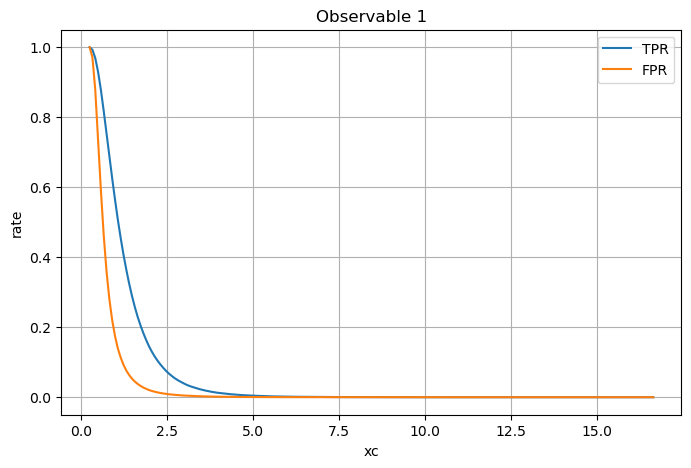

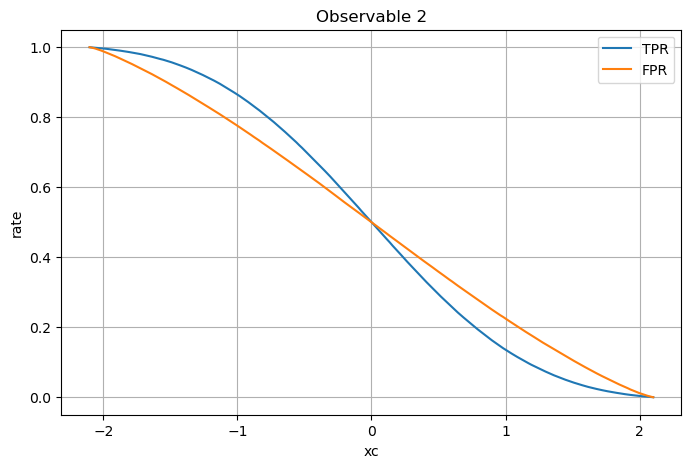

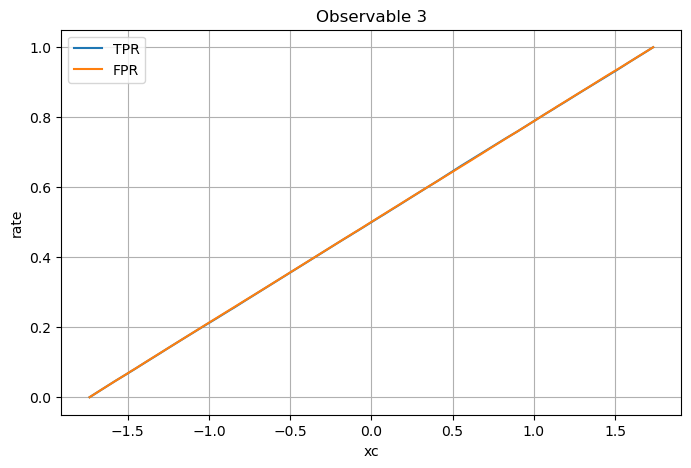

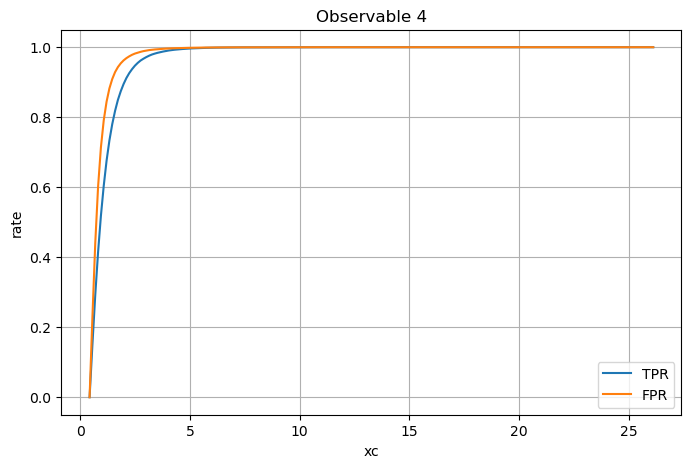

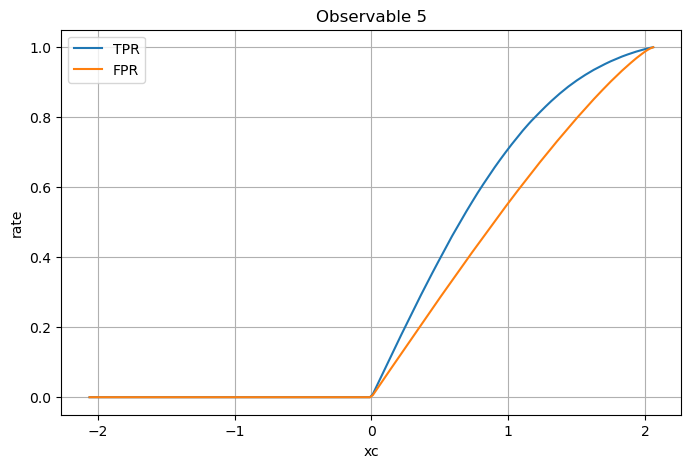

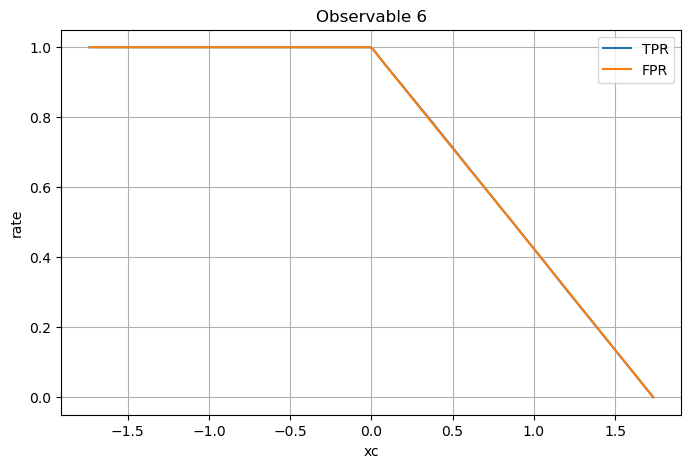

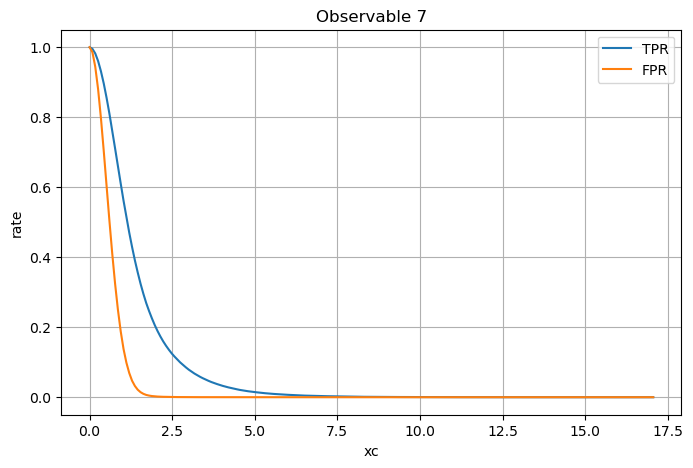

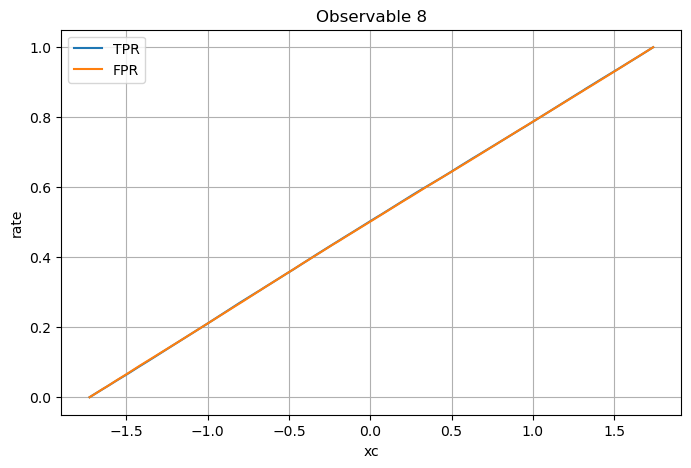

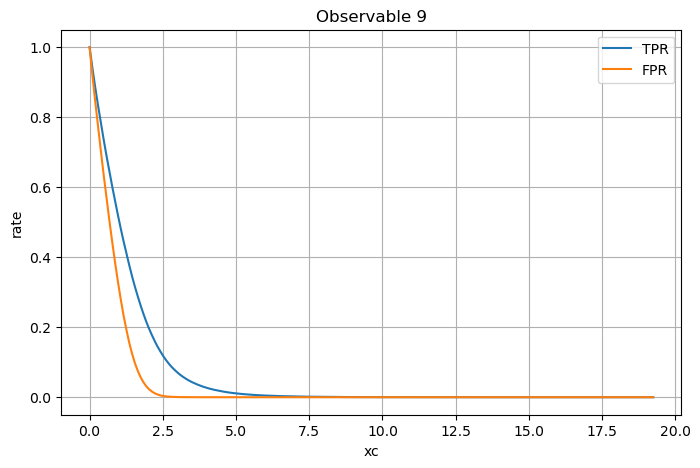

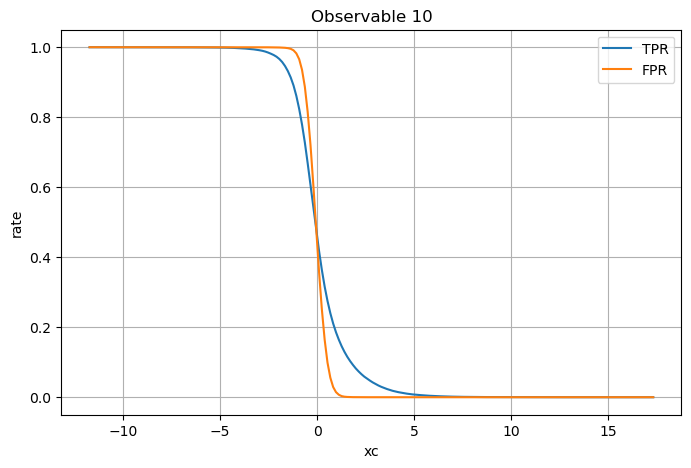

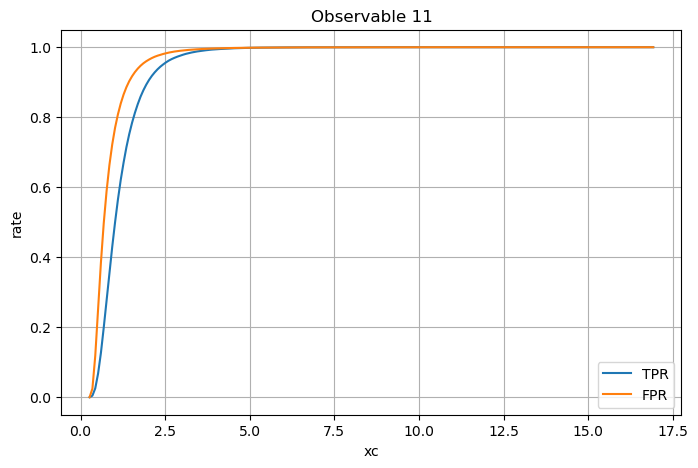

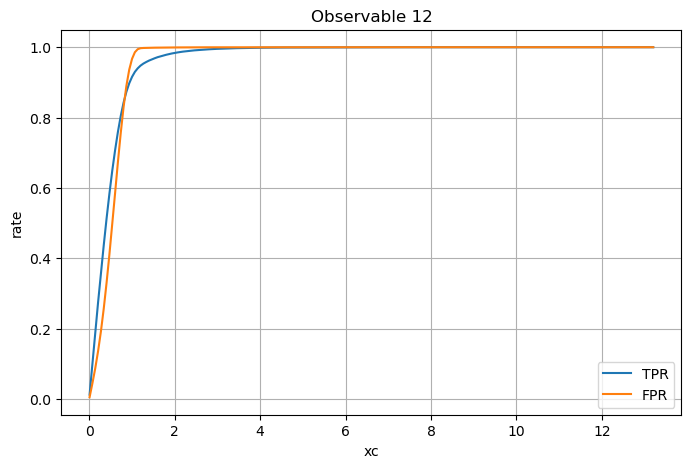

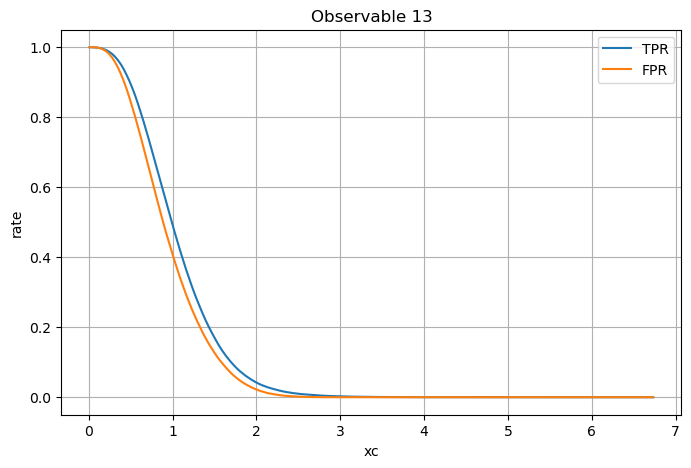

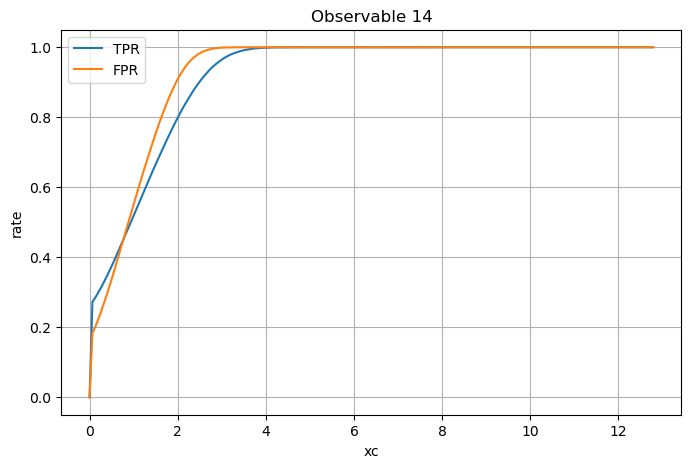

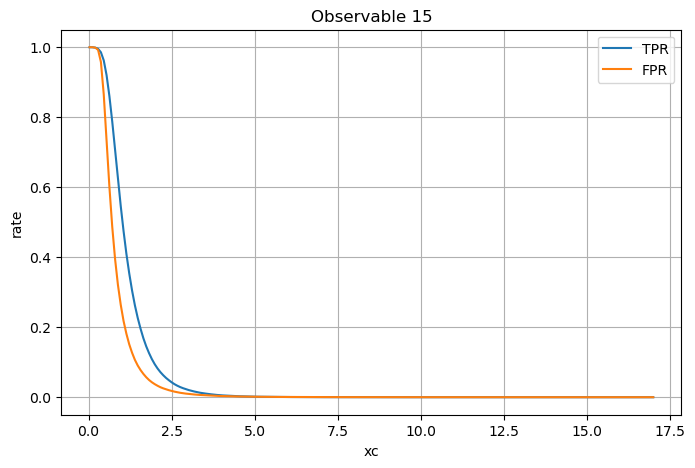

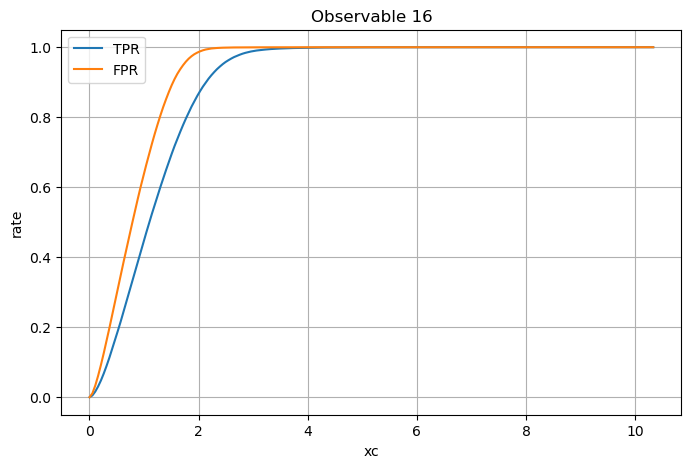

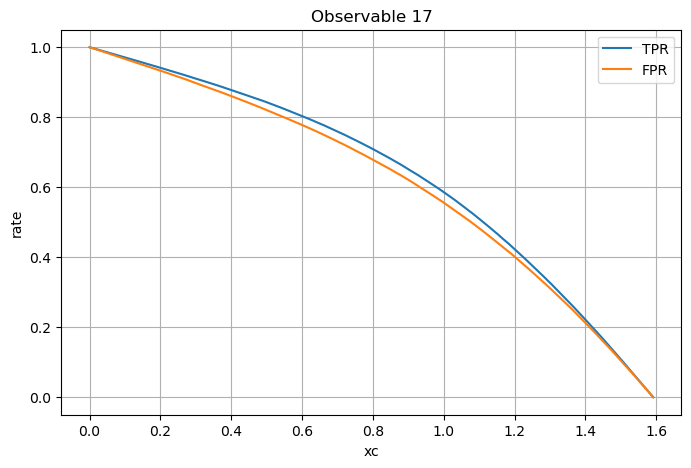

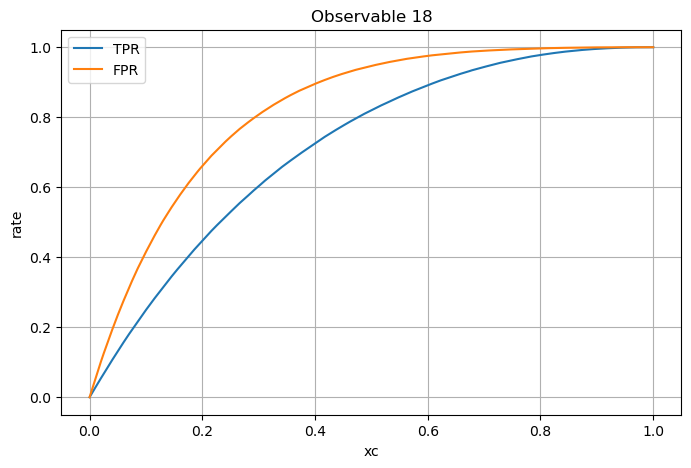

In [50]:
# Ex5.2

# loading the data (same as earlier)
data=np.loadtxt("SUSY-small.csv",delimiter=",")

# splitting the full data into signal and background using truth column - 1 is for signal and 0 is for background
signal=data[data[:,0]==1]
background=data[data[:,0]==0]

# removing first column because it is just the label
sig_x=signal[:,1:]
bkg_x=background[:,1:]

# asked LLM if my answer was going in the correct direction till here, then I proceeded


# choosing the cut type for each observable based on the histograms
# "gt" is for x > xc
# "lt" is for x < xc
# "out" is for |x - mu| > xc
# "in" is for |x - mu| < xc

cut_types=["gt","gt","lt","lt","in","out","gt","lt","gt","gt","lt","in","gt","lt","gt","lt","gt","lt"]


def get_rates(sig_vals ,bkg_vals ,cut_type):
    
    # making a set of xc values across the range of that observable
    xmin=min(np.min(sig_vals),np.min(bkg_vals))
    xmax=max(np.max(sig_vals),np.max(bkg_vals))

    xc_vals=np.linspace(xmin,xmax,200)
    tpr=[]
    fpr=[]
    
    # only for the centered cuts
    mu=np.mean(sig_vals)
    for xc in xc_vals:

        if cut_type=="gt":
            sig_pass=sig_vals>xc
            bkg_pass=bkg_vals>xc

        elif cut_type=="lt":
            sig_pass=sig_vals<xc
            bkg_pass=bkg_vals<xc

        elif cut_type=="out":
            sig_pass=np.abs(sig_vals-mu)>xc
            bkg_pass=np.abs(bkg_vals-mu)>xc

        elif cut_type=="in":
            sig_pass=np.abs(sig_vals-mu)<xc
            bkg_pass=np.abs(bkg_vals-mu)<xc

        # TPR is the fraction of signal that passes
        # FPR is fraction of background that passes
        tpr.append(np.sum(sig_pass)/len(sig_vals))
        fpr.append(np.sum(bkg_pass)/len(bkg_vals))

    return xc_vals ,np.array(tpr) ,np.array(fpr)



for i in range(sig_x.shape[1]):
    sig_vals=sig_x[:,i]
    bkg_vals=bkg_x[:,i]
    xc_vals ,tpr ,fpr=get_rates(sig_vals ,bkg_vals ,cut_types[i])

    plt.figure(figsize=(8,5))
    plt.plot(xc_vals ,tpr ,label="TPR")
    plt.plot(xc_vals ,fpr ,label="FPR")

    plt.xlabel("xc")
    plt.ylabel("rate")
    plt.title("Observable "+str(i+1))
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
## checked with LLM if my output looked right

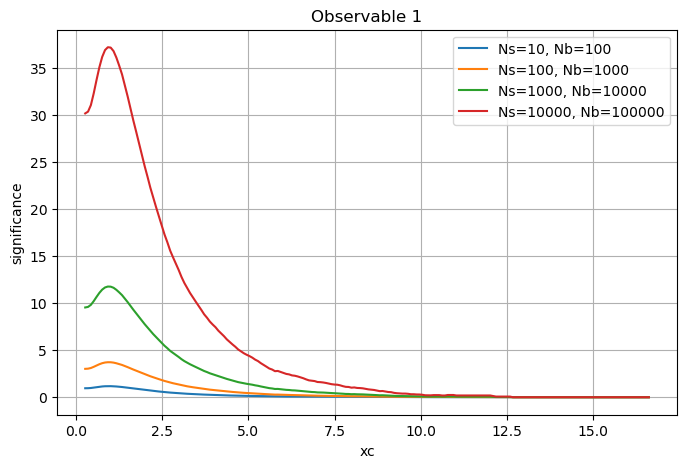

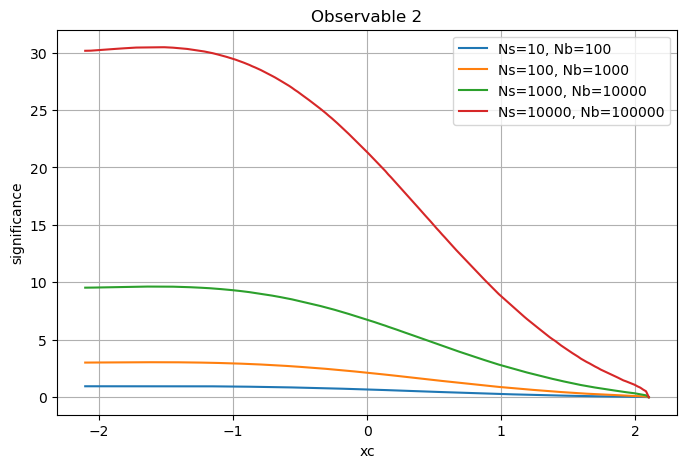

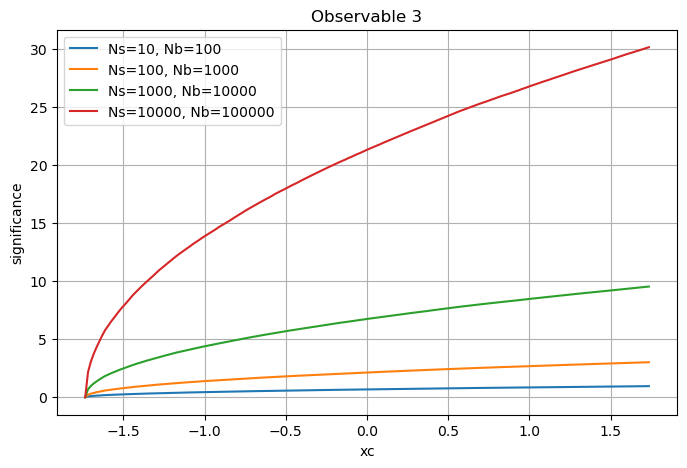

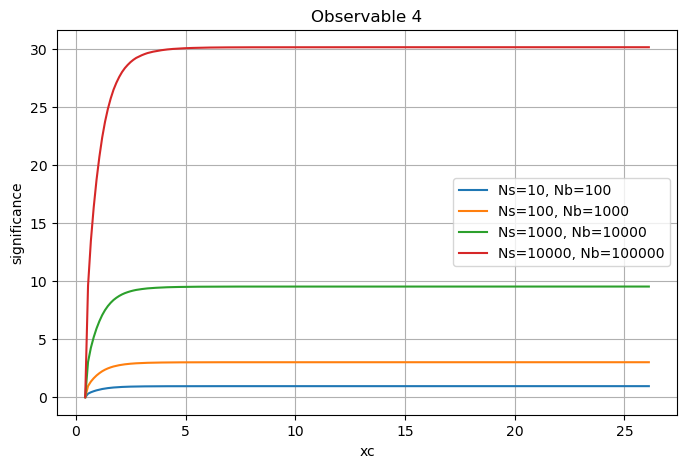

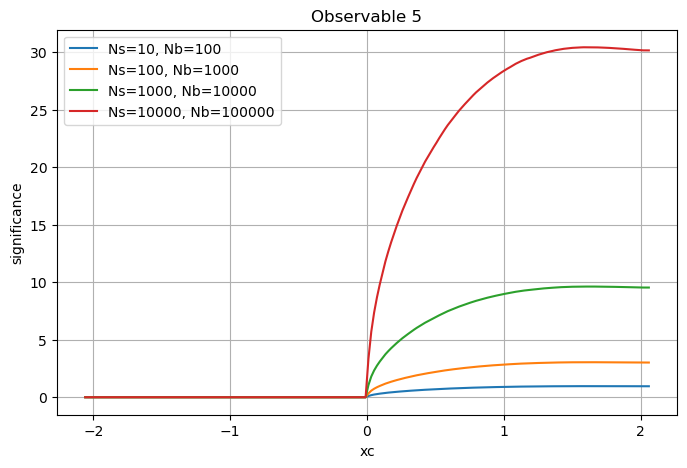

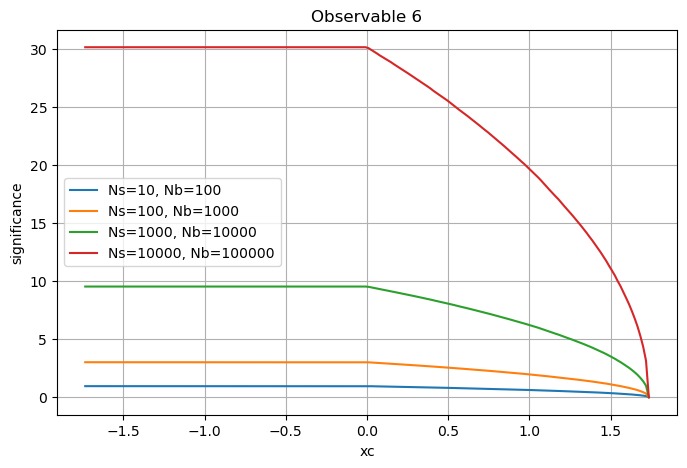

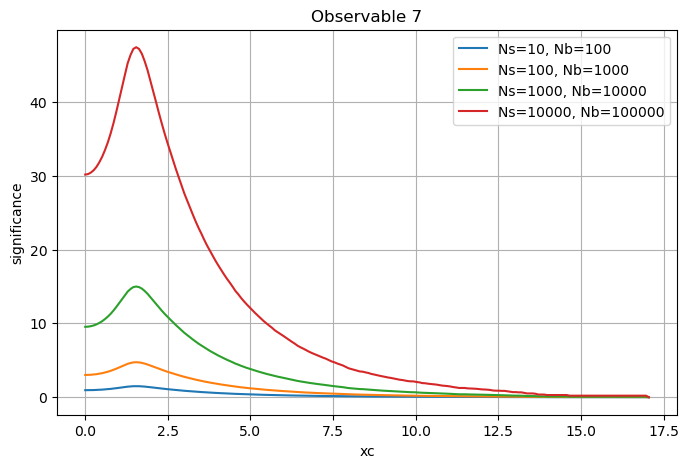

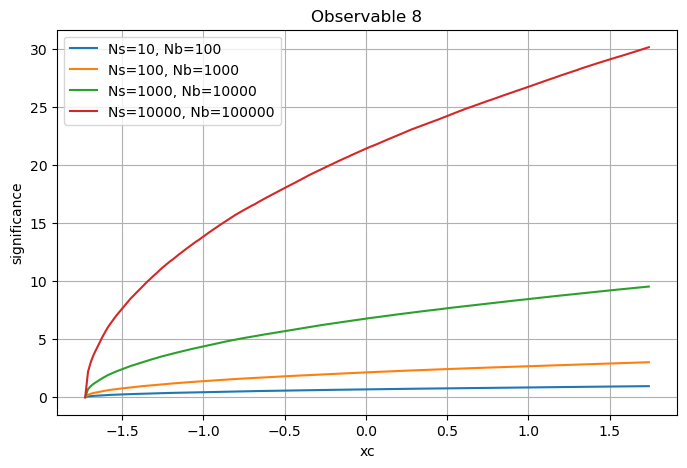

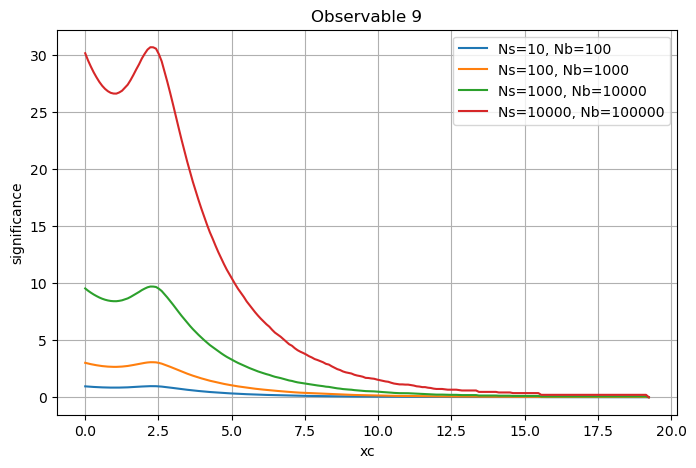

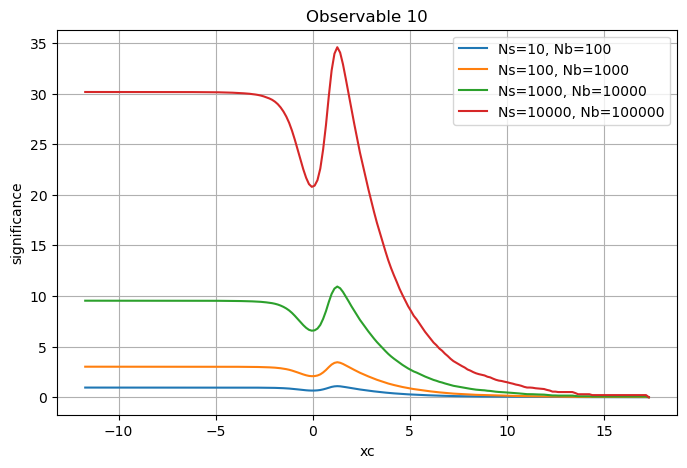

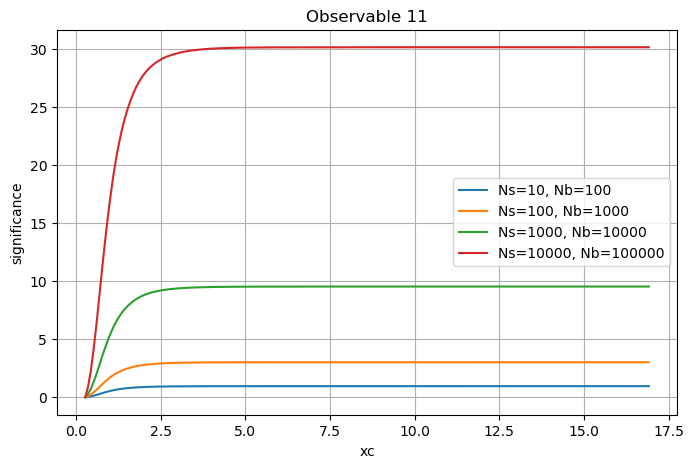

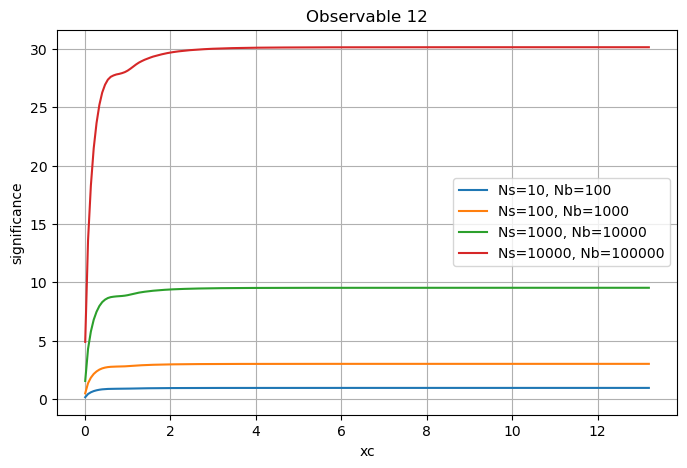

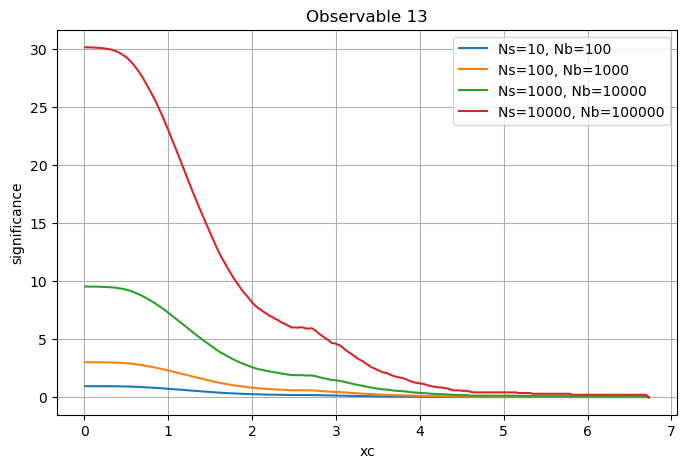

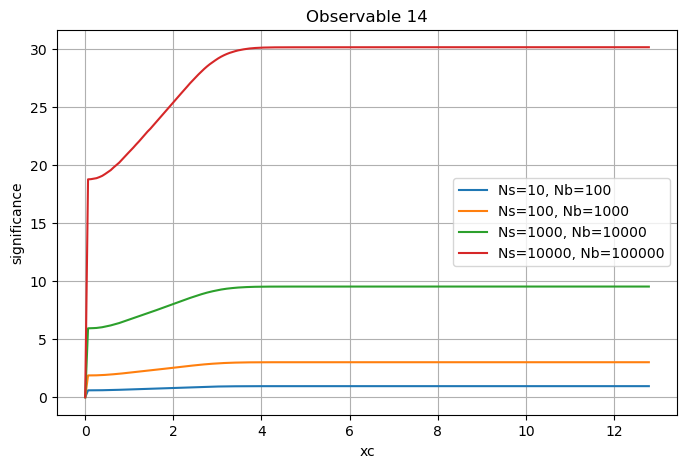

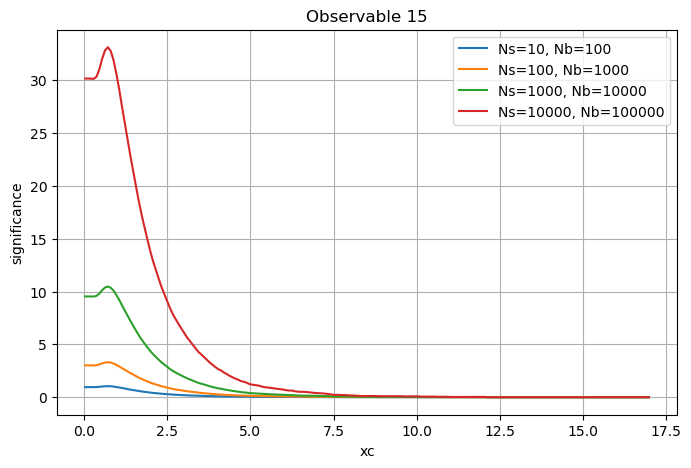

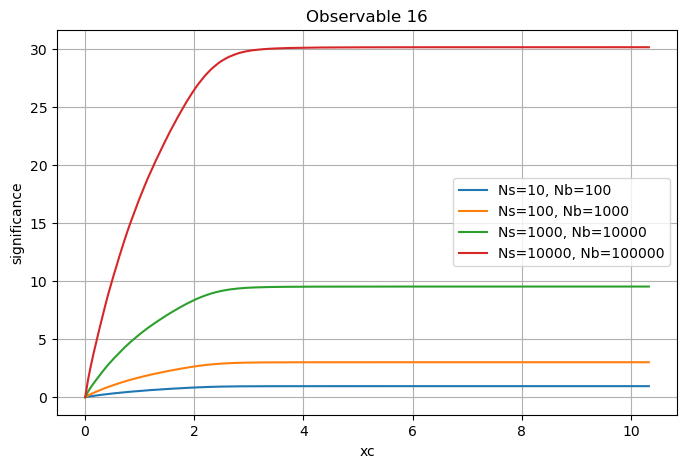

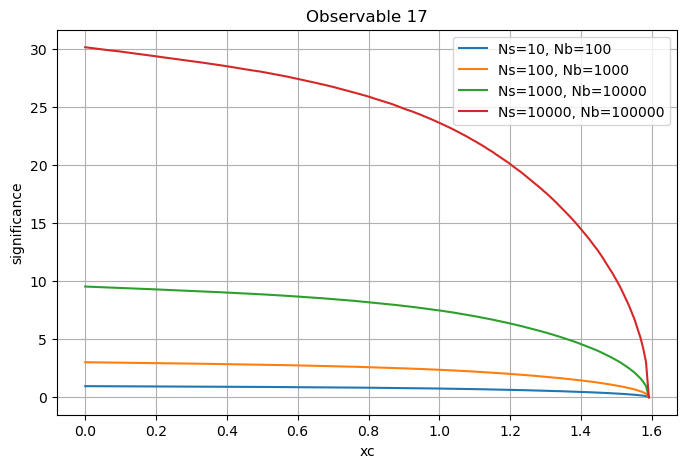

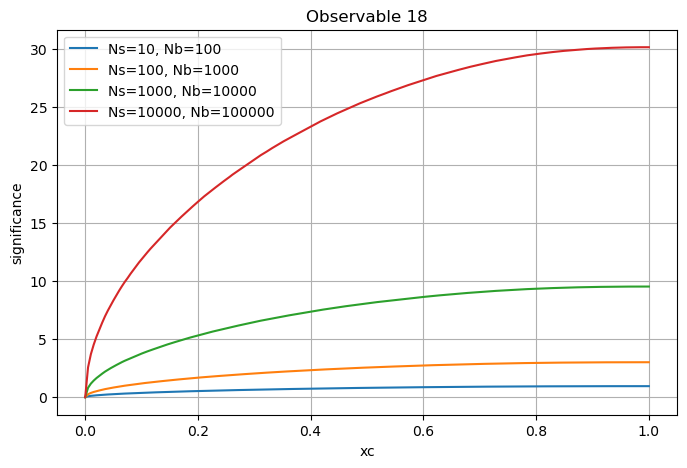

In [51]:
# Ex 5.3

# scenarios given in the question
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]


def get_significance(sig_vals ,bkg_vals ,cut_type ,Ns ,Nb):
    xmin=min(np.min(sig_vals),np.min(bkg_vals))
    xmax=max(np.max(sig_vals),np.max(bkg_vals))
    xc_vals=np.linspace(xmin ,xmax ,200)

    sigma_vals=[]

    mu=np.mean(sig_vals)

    for xc in xc_vals:

        if cut_type=="gt":
            sig_pass=sig_vals>xc
            bkg_pass=bkg_vals>xc

        elif cut_type=="lt":
            sig_pass=sig_vals<xc
            bkg_pass=bkg_vals<xc

        elif cut_type=="out":
            sig_pass=np.abs(sig_vals-mu)>xc
            bkg_pass=np.abs(bkg_vals-mu)>xc

        elif cut_type=="in":
            sig_pass=np.abs(sig_vals-mu)<xc
            bkg_pass=np.abs(bkg_vals-mu)<xc

        # efficiencies
        eps_s=np.sum(sig_pass)/len(sig_vals)
        eps_b=np.sum(bkg_pass)/len(bkg_vals)
        
        # expected events after cut        
        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb
        
        # significance formula
        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0
        sigma_vals.append(sigma)
    return xc_vals ,np.array(sigma_vals)

# looping over observables and scenarios
for i in range(sig_x.shape[1]):
    sig_vals=sig_x[:,i]
    bkg_vals=bkg_x[:,i]
    plt.figure(figsize=(8,5))
    
    for (Ns ,Nb) in scenarios:
        xc_vals ,sigma_vals=get_significance(sig_vals ,bkg_vals ,cut_types[i] ,Ns ,Nb)
        plt.plot(xc_vals ,sigma_vals ,label="Ns="+str(Ns)+", Nb="+str(Nb))

    plt.xlabel("xc")
    plt.ylabel("significance")
    plt.title("Observable "+str(i+1))
    plt.legend()
    plt.grid()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [45]:
## Ex 6.1
## Based on the significance plots from 5.3 I selected some the of observables that showed higher peaks in significance.
# Specifically, Observable 1, 5 and 7. I chose these because they showed better separation between signal and background and 
# they gave higher significance compared to other observables. I chose corresponding xc values near the peak 
# of the significance curves for each scenario.
# Chosen xc values:
# Observable 1: x>1.0 (since theres a clear peak around 1)
# Observable 7: x>2.0 (since theres a strong peaks around 2)
# Observable 5: x>1.5 (since theres an increase in significance and peak around 1.5)

In [52]:
##  Ex 6.2

# indices of selected observables from 6.1
selected_obs=[0,6,4]

# chosen xc values from 6.1
xc_values=[1.0,2.0,1.5]

def apply_cut(values ,cut_type ,xc ,mu): 
    if cut_type=="gt":
        return values>xc
    
    elif cut_type=="lt":
        return values<xc
    
    elif cut_type=="out":
        return np.abs(values-mu)>xc
    
    elif cut_type=="in":
        return np.abs(values-mu)<xc

# four scenarios from the question
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]

for Ns ,Nb in scenarios:
    print("\nScenario: Ns=",Ns,", Nb=",Nb)
    print("Cut   eps_S   eps_B   Ns'    Nb'    sigma_S'")

    sig_mask=np.ones(len(sig_x),dtype=bool)
    bkg_mask=np.ones(len(bkg_x),dtype=bool)

    for j in range(len(selected_obs)):
        obs=selected_obs[j]
        xc=xc_values[j]
        
        sig_vals=sig_x[:,obs]
        bkg_vals=bkg_x[:,obs]
        mu=np.mean(sig_vals)

        sig_pass=apply_cut(sig_vals,cut_types[obs],xc,mu)
        bkg_pass=apply_cut(bkg_vals,cut_types[obs],xc,mu)

        # applying cuts successively
        sig_mask=sig_mask&sig_pass
        bkg_mask=bkg_mask&bkg_pass

        eps_s=np.sum(sig_mask)/len(sig_x)
        eps_b=np.sum(bkg_mask)/len(bkg_x)

        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb

        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0

        print(str(obs+1),"  ",
              round(eps_s,4)," ",
              round(eps_b,4)," ",
              round(Ns_new,2)," ",
              round(Nb_new,2)," ",
              round(sigma,4))


Scenario: Ns= 10 , Nb= 100
Cut   eps_S   eps_B   Ns'    Nb'    sigma_S'
1    1.0   1.0   10.0   100.0   0.9535
7    1.0   1.0   10.0   100.0   0.9535
5    1.0   1.0   10.0   100.0   0.9535

Scenario: Ns= 100 , Nb= 1000
Cut   eps_S   eps_B   Ns'    Nb'    sigma_S'
1    1.0   1.0   100.0   1000.0   3.0151
7    1.0   1.0   100.0   1000.0   3.0151
5    1.0   1.0   100.0   1000.0   3.0151

Scenario: Ns= 1000 , Nb= 10000
Cut   eps_S   eps_B   Ns'    Nb'    sigma_S'
1    1.0   1.0   1000.0   10000.0   9.5346
7    1.0   1.0   1000.0   10000.0   9.5346
5    1.0   1.0   1000.0   10000.0   9.5346

Scenario: Ns= 10000 , Nb= 100000
Cut   eps_S   eps_B   Ns'    Nb'    sigma_S'
1    1.0   1.0   10000.0   100000.0   30.1511
7    1.0   1.0   10000.0   100000.0   30.1511
5    1.0   1.0   10000.0   100000.0   30.1511


In [47]:
## Ex 6.3

# If two variables are strongly correlated, then they are basically giving similar information.
# That can remove extra signals while only giving small reduction in background. This would make the final significance worse
# than expected.

# Based on the correlation matrices and the earlier pair plots, this issue is most likely to happen for observables
# that have similar shapes and very similar behavior in the significance plots. In my case, observables like 1 and 7
# are the situations where this effect can be most harmful.

# I asked LLM to give an approach for correction of this, and understood that basically the better approach would be 
# to apply a cut on just one observable first and keep only the remaining events, then redo the significance scan for the 
# second observable using the reduced data. This would give a more realistic xc for the second variable because it is optimized
# after the first cut has already changed the signal and background distributions.

# If I reverse the order and cut on the second observable first and then optimize the first one, the result can change. 
# This happens because once the first cut is applied, the distributions of the remaining events are different, so the
# best xc for the next variable also changes.

# So when variables are correlated, the order of cuts also matters a lot. In general, it is better to start with 
# the observable that gives the strongest separation first, and then optimize the next cut after that.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



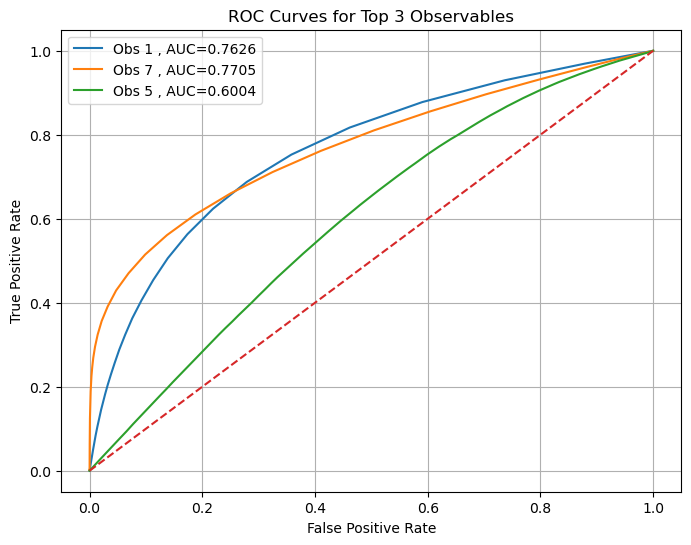

In [49]:
## Ex 7.1

# top 3 observables chosen earlier
top_obs=[0,6,4]      # Observable 1, 7 and 5

def get_roc(sig_vals ,bkg_vals ,cut_type):
    xmin=min(np.min(sig_vals),np.min(bkg_vals))
    xmax=max(np.max(sig_vals),np.max(bkg_vals))

    xc_vals=np.linspace(xmin ,xmax ,200)
    tpr=[]
    fpr=[]
    mu=np.mean(sig_vals)

    for xc in xc_vals:
        if cut_type=="gt":
            sig_pass=sig_vals>xc
            bkg_pass=bkg_vals>xc

        elif cut_type=="lt":
            sig_pass=sig_vals<xc
            bkg_pass=bkg_vals<xc

        elif cut_type=="out":
            sig_pass=np.abs(sig_vals-mu)>xc
            bkg_pass=np.abs(bkg_vals-mu)>xc

        elif cut_type=="in":
            sig_pass=np.abs(sig_vals-mu)<xc
            bkg_pass=np.abs(bkg_vals-mu)<xc

        # TPR is signal efficiency
        # FPR is background efficiency
        tpr.append(np.sum(sig_pass)/len(sig_vals))
        fpr.append(np.sum(bkg_pass)/len(bkg_vals))

    tpr=np.array(tpr)
    fpr=np.array(fpr)
    
    # sort before area calculation
    order=np.argsort(fpr)
    fpr=fpr[order]
    tpr=tpr[order]
    auc=np.trapz(tpr ,fpr)

    return fpr ,tpr ,auc

plt.figure(figsize=(8,6))
for obs in top_obs:
    sig_vals=sig_x[:,obs]
    bkg_vals=bkg_x[:,obs]

    fpr ,tpr ,auc=get_roc(sig_vals ,bkg_vals ,cut_types[obs])

    plt.plot(fpr ,tpr ,label="Obs "+str(obs+1)+" , AUC="+str(round(auc,4)))

# diagonal line for reference
plt.plot([0,1] ,[0,1] ,"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Top 3 Observables")
plt.legend()
plt.grid()
plt.show()

In [55]:
## Ex 7.2

def plot_roc_curves(obs_list ,sig_x ,bkg_x ,cut_types ,title_text):

    plt.figure(figsize=(8,6))

    # looping through each observable in the list
    for obs in obs_list:

        # taking signal and background values for that observable
        sig_vals=sig_x[:,obs]
        bkg_vals=bkg_x[:,obs]

        # making a range of cut values from the minimum to maximum
        xmin=min(np.min(sig_vals),np.min(bkg_vals))
        xmax=max(np.max(sig_vals),np.max(bkg_vals))

        xc_vals=np.linspace(xmin ,xmax ,200)

        tpr=[]
        fpr=[]

        # mean only needed for the centered cuts
        mu=np.mean(sig_vals)

        # going through all cut values to build the ROC curve
        for xc in xc_vals:

            if cut_types[obs]=="gt":
                sig_pass=sig_vals>xc
                bkg_pass=bkg_vals>xc

            elif cut_types[obs]=="lt":
                sig_pass=sig_vals<xc
                bkg_pass=bkg_vals<xc

            elif cut_types[obs]=="out":
                sig_pass=np.abs(sig_vals-mu)>xc
                bkg_pass=np.abs(bkg_vals-mu)>xc

            elif cut_types[obs]=="in":
                sig_pass=np.abs(sig_vals-mu)<xc
                bkg_pass=np.abs(bkg_vals-mu)<xc

            # TPR is the fraction of signal that passes
            # FPR is the fraction of background that passes
            tpr.append(np.sum(sig_pass)/len(sig_vals))
            fpr.append(np.sum(bkg_pass)/len(bkg_vals))

        tpr=np.array(tpr)
        fpr=np.array(fpr)

        order=np.argsort(fpr)
        fpr=fpr[order]
        tpr=tpr[order]

        # area under the ROC curve
        auc=np.trapz(tpr ,fpr)

        # plotting ROC curve 
        plt.plot(fpr ,tpr ,label="Obs "+str(obs+1)+" , AUC="+str(round(auc,4)))

    # reference diagonal line
    plt.plot([0,1] ,[0,1] ,"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title_text)
    plt.legend()
    plt.grid()
    plt.show()


# example use of the function with the top 3 observables
plot_roc_curves([0,6,4] ,sig_x ,bkg_x ,cut_types ,"ROC Curves for Top 3 Observables")

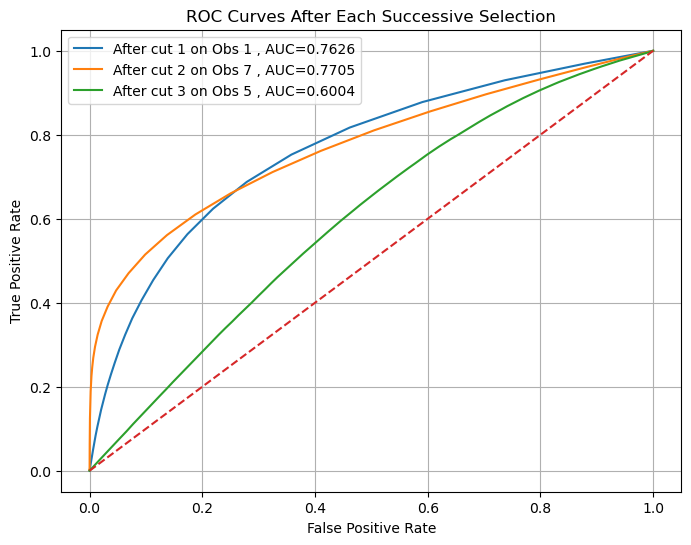

In [58]:
## Ex 7.3

def plot_roc_after_each_selection(selected_obs ,xc_values ,sig_x ,bkg_x ,cut_types):

    sig_mask=np.ones(len(sig_x),dtype=bool)
    bkg_mask=np.ones(len(bkg_x),dtype=bool)

    plt.figure(figsize=(8,6))

    # going through the cuts one by one
    for j in range(len(selected_obs)):

        obs=selected_obs[j]
        xc=xc_values[j]

        # taking values for the current observable
        sig_vals=sig_x[:,obs]
        bkg_vals=bkg_x[:,obs]

        mu=np.mean(sig_vals)

        # applying the next cut using the chosen cut type
        if cut_types[obs]=="gt":
            sig_pass=sig_vals>xc
            bkg_pass=bkg_vals>xc

        elif cut_types[obs]=="lt":
            sig_pass=sig_vals<xc
            bkg_pass=bkg_vals<xc

        elif cut_types[obs]=="out":
            sig_pass=np.abs(sig_vals-mu)>xc
            bkg_pass=np.abs(bkg_vals-mu)>xc

        elif cut_types[obs]=="in":
            sig_pass=np.abs(sig_vals-mu)<xc
            bkg_pass=np.abs(bkg_vals-mu)<xc

        # updating the masks so the cuts are applied successively
        sig_mask=sig_mask&sig_pass
        bkg_mask=bkg_mask&bkg_pass

        # keeping only remaining events after this cut
        sig_now=sig_x[sig_mask]
        bkg_now=bkg_x[bkg_mask]

        # if one group becomes empty, skip that stage
        if len(sig_now)==0 or len(bkg_now)==0:
            continue

        # using the same observable again, but now only on the remaining events
        sig_now_vals=sig_now[:,obs]
        bkg_now_vals=bkg_now[:,obs]

        # making a range of cut values for the ROC curve
        xmin=min(np.min(sig_now_vals),np.min(bkg_now_vals))
        xmax=max(np.max(sig_now_vals),np.max(bkg_now_vals))

        cut_vals=np.linspace(xmin ,xmax ,200)

        tpr=[]
        fpr=[]

        # new mean for centered cuts after selection
        mu_now=np.mean(sig_now_vals)

        # computing TPR and FPR across the cut range
        for cut in cut_vals:

            if cut_types[obs]=="gt":
                sig_keep=sig_now_vals>cut
                bkg_keep=bkg_now_vals>cut

            elif cut_types[obs]=="lt":
                sig_keep=sig_now_vals<cut
                bkg_keep=bkg_now_vals<cut

            elif cut_types[obs]=="out":
                sig_keep=np.abs(sig_now_vals-mu_now)>cut
                bkg_keep=np.abs(bkg_now_vals-mu_now)>cut

            elif cut_types[obs]=="in":
                sig_keep=np.abs(sig_now_vals-mu_now)<cut
                bkg_keep=np.abs(bkg_now_vals-mu_now)<cut

            # TPR is the fraction of remaining signal kept
            # FPR is the fraction of remaining background kept
            tpr.append(np.sum(sig_keep)/len(sig_now_vals))
            fpr.append(np.sum(bkg_keep)/len(bkg_now_vals))

        tpr=np.array(tpr)
        fpr=np.array(fpr)

        order=np.argsort(fpr)
        fpr=fpr[order]
        tpr=tpr[order]

        auc=np.trapz(tpr ,fpr)

        # plotting the ROC curve 
        plt.plot(fpr ,tpr ,label="After cut "+str(j+1)+" on Obs "+str(obs+1)+" , AUC="+str(round(auc,4)))

    # reference diagonal line
    plt.plot([0,1] ,[0,1] ,"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves After Each Successive Selection")
    plt.legend()
    plt.grid()
    plt.show()


# using same observables and xc values chosen earlier
selected_obs=[0,6,4]
xc_values=[1.0,2.0,1.5]

plot_roc_after_each_selection(selected_obs ,xc_values ,sig_x ,bkg_x ,cut_types)

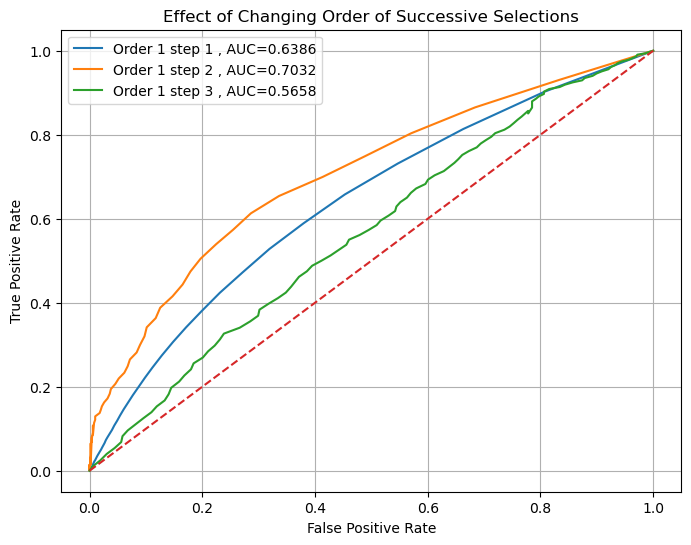

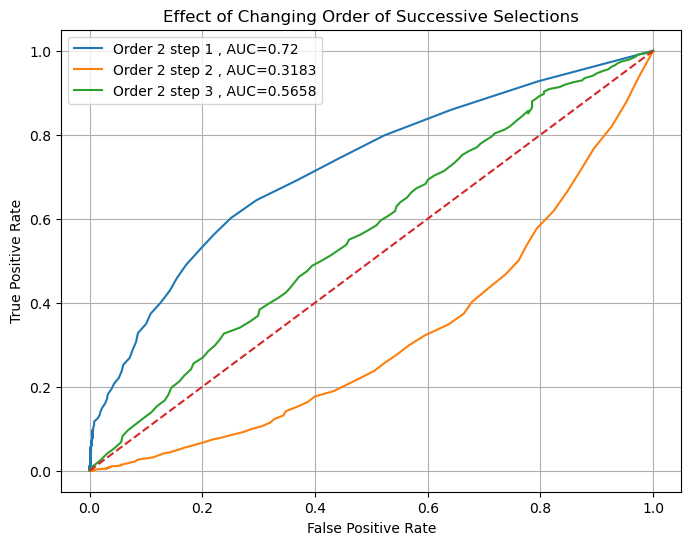

In [61]:
## Ex 7.4

def plot_roc_for_order(selected_obs ,xc_values ,sig_x ,bkg_x ,cut_types ,label_text):

    # starting with all events
    sig_mask=np.ones(len(sig_x),dtype=bool)
    bkg_mask=np.ones(len(bkg_x),dtype=bool)

    plt.figure(figsize=(8,6))

    # applying the cuts in the given order
    for j in range(len(selected_obs)):

        obs=selected_obs[j]
        xc=xc_values[j]

        sig_vals=sig_x[:,obs]
        bkg_vals=bkg_x[:,obs]

        # mean is only needed for centered cuts
        mu=np.mean(sig_vals)

        if cut_types[obs]=="gt":
            sig_pass=sig_vals>xc
            bkg_pass=bkg_vals>xc

        elif cut_types[obs]=="lt":
            sig_pass=sig_vals<xc
            bkg_pass=bkg_vals<xc

        elif cut_types[obs]=="out":
            sig_pass=np.abs(sig_vals-mu)>xc
            bkg_pass=np.abs(bkg_vals-mu)>xc

        elif cut_types[obs]=="in":
            sig_pass=np.abs(sig_vals-mu)<xc
            bkg_pass=np.abs(bkg_vals-mu)<xc

        # updating masks after each cut
        sig_mask=sig_mask & sig_pass
        bkg_mask=bkg_mask & bkg_pass

        # keeping only the remaining events
        sig_now=sig_x[sig_mask]
        bkg_now=bkg_x[bkg_mask]

        # skipping if no events remain
        if len(sig_now)==0 or len(bkg_now)==0:
            continue

        # using the current observable on reduced data
        sig_now_vals=sig_now[:,obs]
        bkg_now_vals=bkg_now[:,obs]

        xmin=min(np.min(sig_now_vals),np.min(bkg_now_vals))
        xmax=max(np.max(sig_now_vals),np.max(bkg_now_vals))

        cut_vals=np.linspace(xmin ,xmax ,200)

        tpr=[]
        fpr=[]

        mu_now=np.mean(sig_now_vals)

        # building the ROC curve for this stage
        for cut in cut_vals:

            if cut_types[obs]=="gt":
                sig_keep=sig_now_vals>cut
                bkg_keep=bkg_now_vals>cut

            elif cut_types[obs]=="lt":
                sig_keep=sig_now_vals<cut
                bkg_keep=bkg_now_vals<cut

            elif cut_types[obs]=="out":
                sig_keep=np.abs(sig_now_vals-mu_now)>cut
                bkg_keep=np.abs(bkg_now_vals-mu_now)>cut

            elif cut_types[obs]=="in":
                sig_keep=np.abs(sig_now_vals-mu_now)<cut
                bkg_keep=np.abs(bkg_now_vals-mu_now)<cut

            tpr.append(np.sum(sig_keep)/len(sig_now_vals))
            fpr.append(np.sum(bkg_keep)/len(bkg_now_vals))

        tpr=np.array(tpr)
        fpr=np.array(fpr)

        # sorting 
        order=np.argsort(fpr)
        fpr=fpr[order]
        tpr=tpr[order]

        auc=np.trapz(tpr ,fpr)

        # plotting ROC 
        plt.plot(fpr ,tpr ,label=label_text+" step "+str(j+1)+" , AUC="+str(round(auc,4)))

    # diagonal reference line
    plt.plot([0,1] ,[0,1] ,"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Effect of Changing Order of Successive Selections")
    plt.legend()
    plt.grid()
    plt.show()


# first order from earlier work
selected_obs_1=[0,6,4]
xc_values_1=[1.0,2.0,1.5]

# now changing the order of the same selections
selected_obs_2=[6,0,4]
xc_values_2=[2.0,1.0,1.5]

plot_roc_for_order(selected_obs_1 ,xc_values_1 ,sig_x ,bkg_x ,cut_types ,"Order 1")
plot_roc_for_order(selected_obs_2 ,xc_values_2 ,sig_x ,bkg_x ,cut_types ,"Order 2")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [63]:
## Ex 8.1
# I asked LLM to help me by giving me an outline (which is most of the # explanations in this ans)

# signal is category 1; background is category 2
# using all observables except the first column because the first column is just the label
signal=data[data[:,0]==1][:,1:]
background=data[data[:,0]==0][:,1:]

# mean vector for each class
m1=np.mean(signal ,axis=0)
m2=np.mean(background ,axis=0)

# for turning them into column vectors for the matrix multiplication works
m1=m1.reshape(-1,1)
m2=m2.reshape(-1,1)

# between-class covariance matrix
# SB=(m2-m1)(m2-m1)^T
diff=m2-m1
S_B=diff @ diff.T

# within-class covariance matrix
# SW= sum over both classes of (x_n - m_i)(x_n - m_i)^T
n_features=signal.shape[1]
S_W=np.zeros((n_features ,n_features))

# adding the contribution from the signal events
for x in signal:
    x=x.reshape(-1,1)
    d=x-m1
    S_W=S_W + d @ d.T

# adding the contribution from the background events
for x in background:
    x=x.reshape(-1,1)
    d=x-m2
    S_W=S_W + d @ d.T


print("m1 shape =",m1.shape)
print("m2 shape =",m2.shape)
print("S_B shape =",S_B.shape)
print("S_W shape =",S_W.shape)

print("\nS_B =")
print(S_B)

print("\nS_W =")
print(S_W)

m1 shape = (18, 1)
m2 shape = (18, 1)
S_B shape = (18, 18)
S_W shape = (18, 18)

S_B =
[[ 2.87970231e-01  4.58922304e-04  4.67467434e-04  1.38148662e-01
   1.54068049e-03  3.66095560e-04  4.13461344e-01 -6.36618070e-04
   2.71136238e-01  8.54657090e-02  1.82331687e-01  2.66557653e-01
   5.53227373e-02  7.37824064e-02  1.74241790e-01  1.84116478e-01
   1.54056891e-02  5.66281031e-02]
 [ 4.58922304e-04  7.31359210e-07  7.44977113e-07  2.20159917e-04
   2.45529768e-06  5.83426339e-07  6.58910580e-04 -1.01454317e-06
   4.32094896e-04  1.36201995e-04  2.90571971e-04  4.24798257e-04
   8.81648006e-05  1.17582959e-04  2.77679548e-04  2.93416294e-04
   2.45511986e-05  9.02450903e-05]
 [ 4.67467434e-04  7.44977113e-07  7.58848582e-07  2.24259293e-04
   2.50101531e-06  5.94289733e-07  6.71179491e-04 -1.03343396e-06
   4.40140500e-04  1.38738075e-04  2.95982420e-04  4.32707998e-04
   8.98064286e-05  1.19772353e-04  2.82849940e-04  2.98879704e-04
   2.50083417e-05  9.19254533e-05]
 [ 1.38148662e-0

w shape = (18, 1)

w =
[[-2.26832982e-06]
 [-5.63688439e-09]
 [-2.10423856e-09]
 [-9.95582982e-07]
 [-3.48452234e-09]
 [-2.70762588e-09]
 [-1.65185357e-06]
 [-2.74241844e-09]
 [-1.39723282e-07]
 [-2.64205675e-07]
 [ 2.72149250e-07]
 [-1.48465692e-07]
 [ 2.11167032e-06]
 [ 3.24040633e-07]
 [ 1.81173242e-06]
 [-1.69348122e-06]
 [ 7.50902836e-08]
 [-5.06860437e-06]]


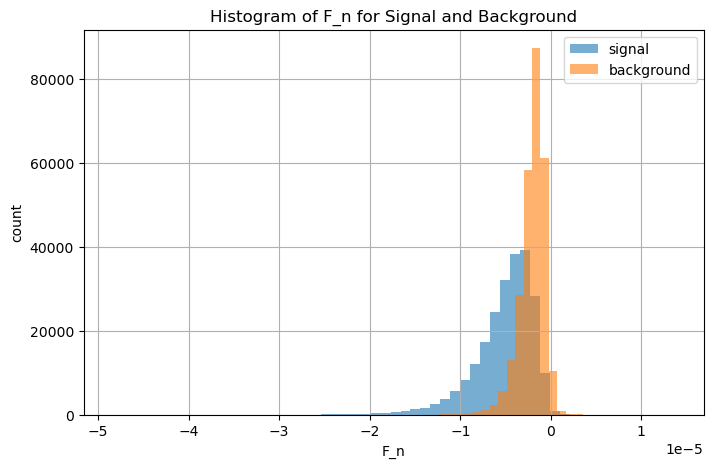

In [64]:
## Ex 8.2
# I wasn't very confident in this either so asked LLM for outline

# computing the linear coefficients
# w = S_W^-1 (m2-m1)
S_W_inv=np.linalg.inv(S_W)
w=S_W_inv @ (m2-m1)

print("w shape =",w.shape)
print("\nw =")
print(w)

# computing F_n = w^T x_n for each event
# using all observables except the first column because the first column is the label
F_signal=[]
F_background=[]

for x in signal:
    x=x.reshape(-1,1)
    F_n=(w.T @ x)[0,0]
    F_signal.append(F_n)

for x in background:
    x=x.reshape(-1,1)
    F_n=(w.T @ x)[0,0]
    F_background.append(F_n)

F_signal=np.array(F_signal)
F_background=np.array(F_background)

# plotting the histograms for the two categories
plt.figure(figsize=(8,5))

plt.hist(F_signal ,bins=50 ,alpha=0.6 ,label="signal")
plt.hist(F_background ,bins=50 ,alpha=0.6 ,label="background")

plt.xlabel("F_n")
plt.ylabel("count")
plt.title("Histogram of F_n for Signal and Background")
plt.legend()
plt.grid()
plt.show()

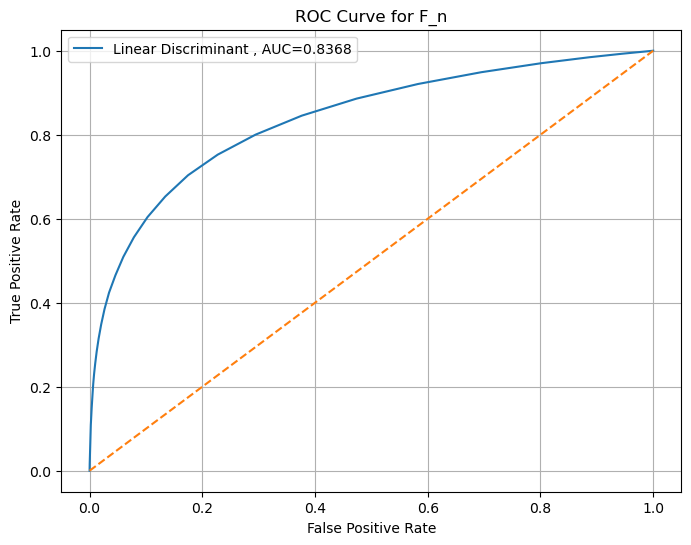

In [66]:
## Ex 8.3

# drawing the ROC curve for F_n

# making a range of cut values from the full F_n distribution
xmin=min(np.min(F_signal),np.min(F_background))
xmax=max(np.max(F_signal),np.max(F_background))

cut_vals=np.linspace(xmin ,xmax ,200)

tpr=[]
fpr=[]

# checking both directions because depending on the sign of w,
# signal may be on the right side or the left side
tpr_gt=[]
fpr_gt=[]

for cut in cut_vals:
    sig_pass=F_signal>cut
    bkg_pass=F_background>cut

    tpr_gt.append(np.sum(sig_pass)/len(F_signal))
    fpr_gt.append(np.sum(bkg_pass)/len(F_background))

tpr_gt=np.array(tpr_gt)
fpr_gt=np.array(fpr_gt)

order=np.argsort(fpr_gt)
fpr_gt=fpr_gt[order]
tpr_gt=tpr_gt[order]

auc_gt=np.trapz(tpr_gt ,fpr_gt)


tpr_lt=[]
fpr_lt=[]

for cut in cut_vals:
    sig_pass=F_signal<cut
    bkg_pass=F_background<cut

    tpr_lt.append(np.sum(sig_pass)/len(F_signal))
    fpr_lt.append(np.sum(bkg_pass)/len(F_background))

tpr_lt=np.array(tpr_lt)
fpr_lt=np.array(fpr_lt)

order=np.argsort(fpr_lt)
fpr_lt=fpr_lt[order]
tpr_lt=tpr_lt[order]

auc_lt=np.trapz(tpr_lt ,fpr_lt)

# choosing the better direction
if auc_gt>=auc_lt:
    fpr=fpr_gt
    tpr=tpr_gt
    auc=auc_gt
else:
    fpr=fpr_lt
    tpr=tpr_lt
    auc=auc_lt

# plotting ROC curve
plt.figure(figsize=(8,6))

plt.plot(fpr ,tpr ,label="Linear Discriminant , AUC="+str(round(auc,4)))
plt.plot([0,1] ,[0,1] ,"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for F_n")
plt.legend()
plt.grid()
plt.show()

In [67]:
## Ex 8.4
# I was a bit confused on how to go about this too so asked LLM for outline

# using the linear discriminant values F_n to find the maximal significance for the same four scenarios from exercise 5
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]

# making a range of cut values from the full F_n distribution
xmin=min(np.min(F_signal),np.min(F_background))
xmax=max(np.max(F_signal),np.max(F_background))

cut_vals=np.linspace(xmin ,xmax ,200)

for Ns ,Nb in scenarios:

    max_sigma=0
    best_cut=None
    best_rule=""

    # checking F_n > cut
    for cut in cut_vals:
        sig_pass=F_signal>cut
        bkg_pass=F_background>cut

        eps_s=np.sum(sig_pass)/len(F_signal)
        eps_b=np.sum(bkg_pass)/len(F_background)

        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb

        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0

        if sigma>max_sigma:
            max_sigma=sigma
            best_cut=cut
            best_rule="F_n > cut"

    # checking F_n < cut
    for cut in cut_vals:
        sig_pass=F_signal<cut
        bkg_pass=F_background<cut

        eps_s=np.sum(sig_pass)/len(F_signal)
        eps_b=np.sum(bkg_pass)/len(F_background)

        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb

        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0

        if sigma>max_sigma:
            max_sigma=sigma
            best_cut=cut
            best_rule="F_n < cut"

    print("Scenario: Ns=",Ns,", Nb=",Nb)
    print("Best rule:",best_rule)
    print("Best cut =",round(best_cut,4))
    print("Max significance =",round(max_sigma,4))
    print()

Scenario: Ns= 10 , Nb= 100
Best rule: F_n < cut
Best cut = -0.0
Max significance = 1.5311

Scenario: Ns= 100 , Nb= 1000
Best rule: F_n < cut
Best cut = -0.0
Max significance = 4.8419

Scenario: Ns= 1000 , Nb= 10000
Best rule: F_n < cut
Best cut = -0.0
Max significance = 15.3113

Scenario: Ns= 10000 , Nb= 100000
Best rule: F_n < cut
Best cut = -0.0
Max significance = 48.4187

